Lưu drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


THƯ VIỆN MÔI TRƯỜNG

In [17]:
# @title
import numpy as np
import copy
import random
from collections import deque
import matplotlib.pyplot as plt
import pickle
import os
import time

# XÂY DỰNG MÔI TRƯỜNG

In [18]:
TOTAL_FLOORS = 3

EMPTY = 0
WALL = 1
KEY = 2
BOMB = 3
HOLE = 4
BLOOD = 5
DOOR = 6
STAIRS_UP = 7
ENTRY = 8
GOAL = 9
MONSTER = 10
SHIELD = 11
SOFT_WALL = 12

# Các hướng di chuyển theo thứ tự: up, right, down, left
DIRS = [(-1, 0), (0, 1), (1, 0), (0, -1)]

# Các tỷ lệ của quái
MONSTER_MISS_WHEN_CHASE = 0.35
MONSTER_STAY = 0.20

# Khoảng cách tối thiểu đặt bomb/ blood
MIN_DIST_PLAYER_BB = 3
MIN_DIST_BB_BB = 3

# Khoảng cách tối thiểu đặt Key-Spawn và Door-Goal
MIN_DIST_SPAWN_KEY = 4
MIN_DIST_DOOR_GOAL = 4

# Số lượng item mỗi floor
MAX_SOFT_WALL_PER_FLOOR = 5
MAX_BOMB_PER_FLOOR = 2
MAX_BLOOD_PER_FLOOR = 3

In [19]:
# @title
class Agent:
    pass
class Monster:
    def __init__(self, floor, y, x, stun=0, chasing=False):
        self.floor = floor
        self.y = y
        self.x = x
        # Biểu thị số bước còn lại để hết choáng
        self.stun = stun
        # Biểu thị có đang đuổi theo người chơi ko
        self.chasing = chasing

In [20]:
# @title
PATTERNS = [
    # Vertical center
    [
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0],
    ],
    # Vertical left
    [
        [0, 0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0],
    ],
    # Vertical right
    [
        [0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1, 0, 0],
    ],
    # Horizontal center
    [
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
    ],
    # Horizontal top
    [
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
    ],
    # Horizontal bottom
    [
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0],
    ],
]


In [21]:
# @title
def manhattan(a, b):
    # Khoảng cách manhattan giữa 2 ô có tọa độ (y, x)
    return abs(a[0] - b[0]) + abs(a[1] - b[1])
def _empty_cells_in_region(floor, region):
    # Lấy danh sách tọa độ ô EMPTY trong vùng
    return [(y, x) for y, x in region if floor[y][x] == EMPTY]

def _bfs_reachable(floor, start, target, allow_door=False):
    # BFS kiểm tra từ start có tới được target hay không.
    if start is None or target is None:
        return False

    rows, cols = len(floor), len(floor[0])

    # Các ô bị chặn: WALL, HOLE và DOOR (nếu allow_door=False). SOFT_WALL bị coi là đi được (để agent có thể dùng búa phá).
    blocked = {WALL, HOLE}
    # Chặn door nếu ko phải là điểm xét ở start hay target
    if not allow_door:
        blocked.add(DOOR)

    # Xem ô mà BFS lan kế tiếp cho phải nằm trong bị chặn hay ngoài biên ko
    def is_passable(y, x):
        if y < 0 or y >= rows or x < 0 or x >= cols:
            return False
        return floor[y][x] not in blocked

    sy, sx = start
    ty, tx = target
    if not is_passable(sy, sx):
        return False

    q = deque([(sy, sx)])
    visited = {(sy, sx)}
    while q:
        y, x = q.popleft()
        if (y, x) == (ty, tx):
            return True
        for dy, dx in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            ny, nx = y + dy, x + dx
            if (ny, nx) not in visited and is_passable(ny, nx):
                visited.add((ny, nx))
                q.append((ny, nx))
    return False


# ====================================================
def generating_floor(floor_index, total_floors):
    # floor_index: 0 = tầng đầu, total_floors-1 = tầng cuối, giữa = tầng giữa.
    # total_floors: tổng số tầng (ít nhất 1)
    for attempt in range(200):

        # BƯỚC 1: CHỌN RANDOM 1 PATTERN CỦA FLOOR VỀ TƯỜNG ĐỂ CHIA LÀM 2 NỬA CHO FLOOR ĐÓ
        p = random.choice(PATTERNS)
        # Gán pattern tường vào floor trống
        floor = [list(row) for row in p]

        # Biến để gán vị trí các bức tường trong floor có pattern mới tạo
        rows, cols = len(floor), len(floor[0])
        wall_cells = [(y, x) for y in range(rows) for x in range(cols) if floor[y][x] == WALL]
        if not wall_cells:
            continue

        # Chọn random 1 trong các vị trí wall để làm cửa, từ đó có ranh giới ngăn 2 vùng
        y_door, x_door = random.choice(wall_cells)
        floor[y_door][x_door] = DOOR

        # BƯỚC 2: Lấy 2 vùng của một floor đã chia ranh giới, regions gồm 2 list region: mỗi list chứa tọa độ các vị trí empty của mỗi region đó
        regions = get_two_regions(floor)
        if regions is None:
            continue

        # BƯỚC 3: Đặt các thành phần quan trọng trước
        # Mỗi region bao gồm key_region và goal_region, 2 phần region này random lẫn nhau trái phải hay trên xuống
        # key_region: đặt ENTRY và KEY
        # goal_region: tầng cuối đặt GOAL, tầng khác đặt STAIRS_UP, và 1 MONSTER
        # Shield đặt mỗi tầng 1 cái ở key_region
        # Hole mỗi tầng đặt 1 cái mỗi region (key_region + goal_region), phải xét sao để đường đi luôn luôn tới được đích

        # entry_pos: Trả về vị trí ENTRY của mỗi tầng
        entry_pos = place_objects(floor, regions, floor_index, total_floors)
        if entry_pos is None:
            # Pattern này không bố trí được đủ item đúng luật -> thử lại pattern khác
            continue

        # BƯỚC 4: Thêm SOFT_WALL (ko thêm trên ENTRY)
        add_soft_walls(floor, max_soft_per_floor=MAX_SOFT_WALL_PER_FLOOR, entry_pos=entry_pos)

        # BƯỚC 5: Kiểm tra lại toàn cục một lần nữa
        if has_required_paths(floor, floor_index, total_floors, entry_pos):
            return floor, entry_pos

        # Nếu vẫn fail thì thử pattern khác

    raise RuntimeError(f"Không generate được floor {floor_index} sau 200 lần thử")


# BƯỚC 2: Lấy 2 vùng của một floor đã chia ranh giới, regions gồm 2 list region: mỗi list chứa tọa độ các vị trí empty của mỗi region đó
def get_two_regions(floor):
    # Coi WALL và DOOR là chặn, không đi xuyên qua
    # Ô chỉ đi được khi là EMPTY hoặc các loại khác không phải tường/cửa
    # Dùng BFS: từ một ô trống, thăm tất cả ô trống nối với nó (4 hướng lên/xuống/trái/phải) mà không đi qua tường/cửa -> được 1 vùng
    # Sau khi có vùng 1, tìm một ô trống chưa thuộc vùng nào, BFS tiếp -> được vùng 2
    # Return [region_0, region_1], mỗi phần là list các (y, x) thuộc vùng đó

    rows, cols = len(floor), len(floor[0])
    blocked = {WALL, DOOR}

    # Xem ô mà BFS lan kế tiếp cho phải nằm trong bị chặn hay ngoài biên ko
    def is_passable(y, x):
        if y < 0 or y >= rows or x < 0 or x >= cols:
            return False
        return floor[y][x] not in blocked

    visited = set()
    regions = []
    for sy in range(rows):
        for sx in range(cols):
            if (sy, sx) in visited or not is_passable(sy, sx):
                continue
            # BFS từ (sy, sx) để lấy hết vùng này
            region = []
            q = deque([(sy, sx)])
            visited.add((sy, sx))
            while q:
                y, x = q.popleft()
                region.append((y, x))
                for dy, dx in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                    ny, nx = y + dy, x + dx
                    if (ny, nx) not in visited and is_passable(ny, nx):
                        visited.add((ny, nx))
                        q.append((ny, nx))
            regions.append(region)

    if len(regions) != 2:
        return None
    return regions

# BƯỚC 3: Đặt các thành phần quan trọng trước
def place_objects(floor, regions, floor_index, total_floors):
    # Đặt object theo 2 vùng:
    # - Tầng không phải tầng cuối: ENTRY + KEY  |  STAIRS_UP + MONSTER
    # - Tầng cuối:                 ENTRY + KEY  |  GOAL + MONSTER

    # Sau đó đặt shield và hole
    # Trả về entry_pos (y, x) là vị trí ENTRY mỗi floor

    rows, cols = len(floor), len(floor[0])
    regions = list(regions)
    random.shuffle(regions)
    key_region, goal_region = regions[0], regions[1]

    key_cells_all = _empty_cells_in_region(floor, key_region)
    goal_cells_all = _empty_cells_in_region(floor, goal_region)
    if not key_cells_all or not goal_cells_all:
        return None

    spawn_y, spawn_x = None, None

    # P1: key_region: ENTRY + KEY, đảm bảo ENTRY và KEY cách nhau tối thiểu X ô manhattan
    random.shuffle(key_cells_all)
    spawn_y, spawn_x = key_cells_all[0]
    floor[spawn_y][spawn_x] = ENTRY
    entry_pos = (spawn_y, spawn_x)

    key_candidates = [cell for cell in key_cells_all[1:] if manhattan(entry_pos, cell) >= MIN_DIST_SPAWN_KEY]
    if not key_candidates:
        return None
    yk, xk = random.choice(key_candidates)
    floor[yk][xk] = KEY

    # P2: goal_region: (STAIRS_UP hoặc GOAL) + MONSTER, cách DOOR tối thiểu X ô manhattan
    door_pos = None
    for y in range(rows):
        for x in range(cols):
            if floor[y][x] == DOOR:
                door_pos = (y, x)
                break
        if door_pos:
            break
    if door_pos is None:
        return None

    goal_cells = [cell for cell in goal_cells_all if manhattan(door_pos, cell) >= MIN_DIST_DOOR_GOAL]
    if len(goal_cells) < 2:
        return None

    random.shuffle(goal_cells)
    primary_y, primary_x = goal_cells[0]
    if floor_index == total_floors - 1:
        floor[primary_y][primary_x] = GOAL
    else:
        floor[primary_y][primary_x] = STAIRS_UP

    ym, xm = goal_cells[1]
    floor[ym][xm] = MONSTER


    # BƯỚC PHỤ: Thêm SHIELD và HOLE sau khi đã đặt xong đường chính
    # Dùng luôn key_region / goal_region đã chọn ở trên (spawn chắc chắn thuộc key_region)
    empties_key = _empty_cells_in_region(floor, key_region)
    empties_goal = _empty_cells_in_region(floor, goal_region)

    # Đặt 1 SHIELD ở key_region (không đè spawn/ entry)
    shield_candidates = [(y, x) for (y, x) in empties_key
                         if not (spawn_y is not None and spawn_x is not None and (y, x) == (spawn_y, spawn_x))]
    if shield_candidates:
        sy, sx = random.choice(shield_candidates)
        floor[sy][sx] = SHIELD
        empties_key = [(y, x) for (y, x) in empties_key if (y, x) != (sy, sx)]

    # Đặt 1 HOLE ở key_region (không đè spawn/ entry)
    hole_key_candidates = [(y, x) for (y, x) in empties_key
                           if not (spawn_y is not None and spawn_x is not None and (y, x) == (spawn_y, spawn_x))]
    if hole_key_candidates:
        hy, hx = random.choice(hole_key_candidates)
        floor[hy][hx] = HOLE

    # Đặt 1 HOLE ở goal_region
    hole_goal_candidates = list(empties_goal)
    if hole_goal_candidates:
        gy, gx = random.choice(hole_goal_candidates)
        floor[gy][gx] = HOLE

    return (spawn_y, spawn_x)


# BƯỚC 4: Thêm SOFT_WALL (ko thêm trên ENTRY)
def add_soft_walls(floor, max_soft_per_floor, entry_pos=None):
    rows, cols = len(floor), len(floor[0])
    candidates = []
    for y in range(rows):
        for x in range(cols):
            if floor[y][x] != EMPTY:
                continue
            if entry_pos is not None and (y, x) == entry_pos:
                continue
            candidates.append((y, x))

    random.shuffle(candidates)
    for i, (y, x) in enumerate(candidates):
        if i >= max_soft_per_floor:
            break
        floor[y][x] = SOFT_WALL


# BƯỚC 5: Kiểm tra lại toàn cục một lần nữa
def has_required_paths(floor, floor_index, total_floors, entry_pos):
    # Kiểm tra lại các đường bắt buộc sau:
    # - ENTRY -> KEY
    # - KEY -> DOOR
    # - DOOR -> STAIRS_UP (tầng không phải tầng cuối) hoặc GOAL (tầng cuối)

    rows, cols = len(floor), len(floor[0])
    key_pos = None
    door_pos = None
    up_pos = None
    goal_pos = None
    for y in range(rows):
        for x in range(cols):
            v = floor[y][x]
            if v == KEY:
                key_pos = (y, x)
            elif v == DOOR:
                door_pos = (y, x)
            elif v == STAIRS_UP:
                up_pos = (y, x)
            elif v == GOAL:
                goal_pos = (y, x)

    # Check đường từ entry tới key
    if not _bfs_reachable(floor, entry_pos, key_pos, allow_door=False):
        return False

    # Check đường từ key tới door
    if not _bfs_reachable(floor, key_pos, door_pos, allow_door=True):
        return False

    # Nếu là tầng cuối thì check door tới goal còn ko thì check tới stair_ups
    if floor_index == total_floors - 1:
        if not _bfs_reachable(floor, door_pos, goal_pos, allow_door=True):
            return False
    else:
        if not _bfs_reachable(floor, door_pos, up_pos, allow_door=True):
            return False

    return True


# BƯỚC 6: Mỗi board sẽ generate ra các floor khác nhau, từ đó truyền vào initPos nếu ở tầng 0
def generate_board_and_initPos(total_floors, seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    board = []
    entry0 = None
    for fi in range(total_floors):
        floor, entry_pos = generating_floor(floor_index=fi, total_floors=total_floors)
        board.append(floor)
        if fi == 0:
            entry0 = entry_pos

    initPos = (0, int(entry0[0]), int(entry0[1]))
    return board, initPos


In [22]:
# @title
class MazeEnv:
    def __init__(self, board, rewards, initPos):
        # Sơ đồ mê cung
        self.initBoard = board # shape: [floors][rows][cols] -> 3D
        # Các điểm cộng/ trừ
        self.rewards = rewards
        # Bao gồm (floor, y, x) cho biết vị trí hiện tại
        self.initPos = initPos
        # Máu tối đa
        self.maxHP = 3

        # Biến đại diện cho số step tối đa thực hiện mỗi lượt chơi/ theo dõi số step
        self.maxSteps = 300
        self.stepCount = 0

        # ENTRY vị trí xuất hiện của từng tầng
        self.entryPosByFloor = {}
        self.getFloorInformation() # Gán thông tin vào biến trên, mỗi khi khởi tạo hoặc reset lại map

        # Biến chứa vị trí monster trên map, để biểu thị sau, vì monster là vật thể động còn map là tĩnh
        # Monster vision đại diện cho khoảng cách manhanttan từ monster đến player để monster thực hiện đuổi theo nếu trong phạm vi
        # MonsterStun: Số step monster phải trải qua nếu bị stun
        self.monsters = []
        self.monsterVision = 3
        self.monsterStun = 2

        # Búa
        # Số bước cần để hồi búa trước khi dùng - lớn hơn monsterStun để ko có chuyện reward hacking
        self.hammerCooldown = 3
        # Số bước còn lại để hồi búa/ biến theo dõi
        self.hammerTimer = 0

        # Spawn động Bomb / Máu
        # Mỗi tầng tối đa m bomb, n máu tồn tại cùng lúc
        self.maxBombPerFloor = MAX_BOMB_PER_FLOOR
        self.maxBloodPerFloor = MAX_BLOOD_PER_FLOOR
        # Sau một số bước ngẫu nhiên trong [min,max] sẽ spawn 1 bomb hoặc 1 máu
        self.itemSpawnMinSteps = 5
        self.itemSpawnMaxSteps = 7
        self.stepsSinceItemSpawn = 0
        self.nextItemSpawnSteps = random.randint(self.itemSpawnMinSteps, self.itemSpawnMaxSteps)

        # Early-stop nếu agent không tạo tiến triển nhiệm vụ trong quá nhiều bước liên tiếp.
        # Ngưỡng này sẽ tự co giãn theo maxSteps để tránh hardcode.
        self.stagnationRatio = 0.38
        self.minNoProgressSteps = 20
        self.maxNoProgressSteps = max(self.minNoProgressSteps, int(self.maxSteps * self.stagnationRatio))
        self.noProgressSteps = 0

        # Biến lưu loại kết thúc episode
        self.end_reason = None
        # Intrinsic motivation (novelty): thưởng nhỏ khi agent đi tới ô mới trong cùng episode
        self.novelty_bonus = float(self.rewards.get("novelty_bonus", 0.0))

        self.reset()


    # ====================================================
    def getState(self, context=None):
        if isinstance(context, Agent):
            # 12 ô hình kim cương xung quanh
            cell_up = self.getCell(self.y - 1, self.x)
            cell_down = self.getCell(self.y + 1, self.x)
            cell_left = self.getCell(self.y, self.x - 1)
            cell_right = self.getCell(self.y, self.x + 1)

            cell_up2 = self.getCell(self.y - 2, self.x)
            cell_down2 = self.getCell(self.y + 2, self.x)
            cell_left2 = self.getCell(self.y, self.x - 2)
            cell_right2 = self.getCell(self.y, self.x + 2)

            cell_ul = self.getCell(self.y - 1, self.x - 1)
            cell_ur = self.getCell(self.y - 1, self.x + 1)
            cell_dl = self.getCell(self.y + 1, self.x - 1)
            cell_dr = self.getCell(self.y + 1, self.x + 1)

            # Búa sẵn sàng nếu số bước còn lại để hồi búa là 0
            hammer_ready = 1 if self.hammerTimer == 0 else 0

            # Đại diện cho vị trí quái so với agent: 0 = không thấy trong 12 ô, 1..12 = ô tương ứng, 13 = trùng vị trí agent
            monster_cell_index = self.getMonsterCellIndex()
            # Quái có đang stun hay không (0/1)
            monster_stun_flag = self.getMonsterStunFlag()

            # HP rời rạc: 0 = nguy hiểm (hp <= 1), 1 = ổn (hp >= 2) -> giảm state space
            hp_state = 0 if self.hp <= 1 else 1

            return (
                self.floor, hp_state, self.key, self.shield,

                cell_up, cell_down, cell_left, cell_right,
                cell_up2, cell_down2, cell_left2, cell_right2,
                cell_ul, cell_ur, cell_dl, cell_dr,

                monster_cell_index, monster_stun_flag, hammer_ready
            )

        else:
            return (copy.deepcopy(self.board), self.floor, self.y, self.x, self.hp, self.key, self.score, self.hammerTimer)


    # ====================================================
    # Dùng khi chơi trên map để respawn lại nhân vật khi trúng hole hoặc quái nếu ko có khiên
    def getFloorStartPos(self, floor):
        if floor in self.entryPosByFloor:
            return self.entryPosByFloor[floor]

        fb = self.initBoard[floor]
        for y, row in enumerate(fb):
            for x, cell in enumerate(row):
                if cell == ENTRY:
                    return (y, x)

        return (self.initPos[1], self.initPos[2])

    # Gán vị trí entry vào trong cache entry
    def getFloorInformation(self):
        # Cache vị trí ENTRY cho từng tầng từ initBoard (map tĩnh)
        self.entryPosByFloor = {}
        for f, floor in enumerate(self.initBoard):
            floor_np = np.array(floor)
            down = np.where(floor_np == ENTRY)
            if len(down[0]) > 0:
                self.entryPosByFloor[f] = (int(down[0][0]), int(down[1][0]))


    # ====================================================
    # Ô tại vị trí y,x là loại gì
    def getCell(self, y, x):
        floor_board = self.board[self.floor]
        rows = len(floor_board)
        cols = len(floor_board[0])
        if y < 0 or y >= rows or x < 0 or x >= cols:
            # Coi ngoài map là tường
            return WALL

        return int(floor_board[y][x])

    def isTerm(self):
        return self.isFinished

    def isWall(self, cell):
        if cell == WALL or cell == SOFT_WALL:
            return True
        if cell == DOOR and self.key == 0:
            return True
        return False

    def getCells12(self):
        # 12 ô xung quanh agent theo đúng thứ tự dùng cho state và monster
        return [
            (self.y - 1, self.x), (self.y + 1, self.x), (self.y, self.x - 1), (self.y, self.x + 1),
            (self.y - 2, self.x), (self.y + 2, self.x), (self.y, self.x - 2), (self.y, self.x + 2),
            (self.y - 1, self.x - 1), (self.y - 1, self.x + 1), (self.y + 1, self.x - 1), (self.y + 1, self.x + 1),
        ]


    # ====================================================
    def getMonsterCellIndex(self):
        # Vị trí quái trong 12 ô quanh agent:
        # - 0 = không có trong 12 ô
        # - 1..12 = quái nằm ở ô nào (cùng thứ tự như getState)
        # - 13 = quái trùng vị trí agent
        # Thứ tự: up, down, left, right, up2, down2, left2, right2, ul, ur, dl, dr
        for m in self.monsters:
            if m.floor == self.floor and m.y == self.y and m.x == self.x:
                return 13

        cells_12 = self.getCells12()

        for idx, (my, mx) in enumerate(cells_12):
            for m in self.monsters:
                if m.floor == self.floor and m.y == my and m.x == mx:
                    return idx + 1  # 1..12
        return 0

    def getMonsterStunFlag(self):
        # Cờ stun quái trên tầng hiện tại cho state (giả định mỗi tầng tối đa 1 quái như generator hiện tại)
        # 0 = quái không stun (hoặc không có quái trên tầng hiện tại)
        # 1 = quái đang stun
        for m in self.monsters:
            if m.floor == self.floor:
                return 1 if m.stun > 0 else 0
        return 0

    # Ô này có chặn quái, ko cho nó đi vào ko
    def isMonsterBlocked(self, cell):
        if cell in [WALL, SOFT_WALL, DOOR, HOLE, BOMB]:
            return True
        return False

    # Mỗi tầng có duy nhất 1 monster và vị trí spawn của nó sẽ được đặt kĩ lưỡng
    def moveMonsters(self):
        for monster in self.monsters:
            # Nếu vị trí của monster trong self.monster ko nằm ở tầng cùng agent thì ko di chuyển
            if monster.floor != self.floor:
                continue

            my = monster.y
            mx = monster.x

            # Xử lý stun
            if monster.stun > 0:
                monster.stun -= 1
                monster.chasing = False
                continue

            # Tính khoảng cách manhattan để xét nằm trong phạm vi đuổi theo ko
            dist = abs(my - self.y) + abs(mx - self.x)
            if dist <= self.monsterVision:
                monster.chasing = True

                # % chance hụt bước khi đang đuổi
                if random.random() < MONSTER_MISS_WHEN_CHASE:
                    continue

                # Chase player
                moves = DIRS.copy()   # [(-1,0),(0,1),(1,0),(0,-1)]
                random.shuffle(moves)

                # Ưu tiên hướng giảm Manhattan distance
                def manhattan_after_move(m):
                    return abs((my + m[0]) - self.y) + abs((mx + m[1]) - self.x)

                moves.sort(key=manhattan_after_move)

            # Không thì di chuyển random
            else:
                monster.chasing = False

                # % tỷ lệ đứng yên
                if random.random() < MONSTER_STAY:
                    continue

                moves = DIRS.copy()
                random.shuffle(moves)

            # Thực hiện di chuyển quái
            for dy,dx in moves:
                ny = my + dy
                nx = mx + dx
                if not self.isMonsterBlocked(self.getCell(ny, nx)):
                    monster.y = ny
                    monster.x = nx
                    break

    # Event xảy ra khi quái và người chơi va chạm nhau
    def checkMonsterCollision(self, reward, prev_player_pos=None, prev_monster_positions=None):
        # Khi quái và người chơi va chạm nhau - nghĩa là cả 2 cùng cell, thì respawn cả 2 về lại vị trí ban đầu của chúng mỗi tầng
        for i, monster in enumerate(self.monsters):
            same_cell_collision = (
                monster.floor == self.floor and monster.y == self.y and monster.x == self.x
            )

            # Va chạm kiểu "đi xuyên": player và monster đổi vị trí cho nhau trong cùng 1 step.
            crossing_collision = False
            if (
                not same_cell_collision
                and prev_player_pos is not None
                and prev_monster_positions is not None
                and i in prev_monster_positions
            ):
                prev_floor, prev_my, prev_mx = prev_monster_positions[i]
                curr_player = (self.y, self.x)
                player_moved = curr_player != prev_player_pos

                if (
                    player_moved
                    and prev_floor == self.floor
                    and monster.floor == self.floor
                    and (prev_my, prev_mx) == curr_player
                    and (monster.y, monster.x) == prev_player_pos
                ):
                    crossing_collision = True

            if same_cell_collision or crossing_collision:
                # Nếu monster đang stun thì không gây damage cho player
                if monster.stun > 0:
                    continue

                if self.shield == 1: # Có khiên chặn quái
                    self.shield = 0
                    reward += self.rewards["shield_block"]

                    # Stun monster x step
                    monster.stun = self.monsterStun

                    return reward, True
                else:
                    # Trừ điểm cho việc bị trúng quái
                    self.hp -= 1
                    reward += self.rewards["monster"]

                # Respawn player
                self.y, self.x = self.getFloorStartPos(self.floor)

                # Respawn monster
                monster.floor, monster.y, monster.x = self.monsterSpawn[i]
                monster.stun = 0

                if self.hp <= 0:
                    reward += self.rewards["death"]
                    self.isFinished = True
                    self.end_reason = "death"

                return reward, True
        return reward, False


    # ====================================================
    # Spawn động Bomb / Máu theo số step
    def spawnBombBlood(self):
        # Không spawn nếu game đã kết thúc
        if self.isFinished:
            return

        # Tăng bộ đếm step cho spawn
        self.stepsSinceItemSpawn += 1
        if self.stepsSinceItemSpawn < self.nextItemSpawnSteps:
            return

        # Đến ngưỡng spawn: chọn 1 ô EMPTY hợp lệ trên tầng hiện tại
        f = self.floor
        fb = self.board[f]
        rows = len(fb)
        cols = len(fb[0])

        # Tập vị trí monster trên tầng hiện tại
        monster_cells = {(m.y, m.x) for m in self.monsters if m.floor == f}
        # Tập vị trí bomb / máu hiện có trên tầng hiện tại
        bomb_cells = []
        blood_cells = []
        for y in range(rows):
            for x in range(cols):
                if fb[y][x] == BOMB:
                    bomb_cells.append((y, x))
                elif fb[y][x] == BLOOD:
                    blood_cells.append((y, x))

        candidates = []
        for y in range(rows):
            for x in range(cols):
                if fb[y][x] != EMPTY:
                    continue
                # Không spawn dưới player
                if (y, x) == (self.y, self.x):
                    continue
                # Không spawn dưới monster
                if (y, x) in monster_cells:
                    continue
                # Không spawn quá gần player (Manhattan < MIN_DIST_PLAYER_BB)
                if abs(y - self.y) + abs(x - self.x) < MIN_DIST_PLAYER_BB:
                    continue
                # Không spawn quá gần bomb/máu hiện có (Manhattan < MIN_DIST_BB_BB)
                too_close_item = False
                for (iy, ix) in bomb_cells:
                    if abs(y - iy) + abs(x - ix) < MIN_DIST_BB_BB:
                        too_close_item = True
                        break
                if too_close_item:
                    continue
                for (iy, ix) in blood_cells:
                    if abs(y - iy) + abs(x - ix) < MIN_DIST_BB_BB:
                        too_close_item = True
                        break
                if too_close_item:
                    continue
                candidates.append((y, x))

        if not candidates:
            # Không có ô phù hợp, reset timer
            self.stepsSinceItemSpawn = 0
            self.nextItemSpawnSteps = random.randint(self.itemSpawnMinSteps, self.itemSpawnMaxSteps)
            return

        # Đếm bomb / máu hiện có trên tầng
        bomb_count = len(bomb_cells)
        blood_count = len(blood_cells)

        if bomb_count >= self.maxBombPerFloor and blood_count >= self.maxBloodPerFloor:
            # Đủ số lượng cả hai loại
            self.stepsSinceItemSpawn = 0
            self.nextItemSpawnSteps = random.randint(self.itemSpawnMinSteps, self.itemSpawnMaxSteps)
            return

        # Quyết định spawn Bomb hay Máu
        if bomb_count >= self.maxBombPerFloor and blood_count < self.maxBloodPerFloor:
            spawn_type = BLOOD
        elif blood_count >= self.maxBloodPerFloor and bomb_count < self.maxBombPerFloor:
            spawn_type = BOMB
        else:
            # Cả hai đều dưới ngưỡng chọn ngẫu nhiên 50/50
            spawn_type = BOMB if random.random() < 0.5 else BLOOD

        # Chọn ô ngẫu nhiên
        y, x = random.choice(candidates)
        fb[y][x] = spawn_type

        # Đặt lại timer cho lần spawn tiếp theo
        self.stepsSinceItemSpawn = 0
        self.nextItemSpawnSteps = random.randint(self.itemSpawnMinSteps, self.itemSpawnMaxSteps)


    # ====================================================
    def reset(self, seed=None, randomize_map=True):
        # Nếu truyền seed thì cố định lại random theo seed, dùng cho train để so sánh các thuật toán train cùng seed với nhau
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        if randomize_map:
            # Sinh lại map mới dựa trên số tầng hiện tại của initBoard
            # Map sẽ phụ thuộc vào seed truyền vào reset (nếu có),
            # giúp chuỗi map random lặp lại được khi dùng cùng seed.
            floorAmount = len(self.initBoard)
            try:
                newBoard, newInitPos = generate_board_and_initPos(floorAmount, seed=seed)
            except RuntimeError as e:
                # Nếu gen map mới thất bại (sau 200 lần thử), giữ nguyên map cũ để không làm dừng quá trình train
                print(f"Reset() giữ nguyên map cũ vì generate_board_and_initPos fail: {e}")
            else:
                self.initBoard = newBoard
                self.initPos = newInitPos

                # Xóa cache respawn cũ, lấy vị trí ENTRY của map mới
                self.getFloorInformation()

        # Đồng bộ ngưỡng stagnation theo maxSteps hiện tại.
        self.maxNoProgressSteps = max(self.minNoProgressSteps, int(self.maxSteps * self.stagnationRatio))

        # Reset timer spawn động Bomb/Máu
        self.stepsSinceItemSpawn = 0
        self.nextItemSpawnSteps = random.randint(self.itemSpawnMinSteps, self.itemSpawnMaxSteps)

        self.board = [np.array(floor) for floor in self.initBoard]
        self.floor, self.y, self.x = self.initPos

        self.score = 0.0
        self.hp = self.maxHP
        self.key = 0
        self.shield = 0
        self.isFinished = False
        self.stepCount = 0
        self.end_reason = None

        # Reset lại board, có vị trí monster ban đầu
        # Biến chứa vị trí monster trên map, lưu vị trí của chúng để quản lý riêng, vì monster là vật thể động còn map là tĩnh
        self.monsters = []
        # Biến lưu vị trí spawn của monster để monster respawn nếu trúng player
        self.monsterSpawn = []
        for f, floor in enumerate(self.board):
            for y, row in enumerate(floor):
                for x, cell in enumerate(row):
                    if cell == MONSTER:
                        # Đưa tọa độ vào biến để quản lý động monster
                        self.monsters.append(Monster(f, y, x))
                        # Đưa tọa độ vào biến để biết vị trí cần đặt respawn monster
                        self.monsterSpawn.append((f,y,x))
                        # Xóa thành phần monster tĩnh ra khỏi map
                        self.board[f][y][x] = EMPTY

        self.hammerTimer = 0 # Búa sẵn sàng khi bắt đầu

        self.noProgressSteps = 0 # reset bộ đếm tiến độ
        # Reset tập các ô đã thăm trong episode này.
        # Để tránh thưởng ngay tại vị trí khởi đầu, ta đánh dấu ô start là đã thăm.
        # dict đếm số lần thăm (pos_key -> count)
        self.visited_this_episode = {(self.floor, self.y, self.x): 1}
        return self.getState()

    # ====================================================
    def getPosActions(self):
        if self.isFinished:
            return []

        actions = []

        # UP: 0
        if not self.isWall(self.getCell(self.y - 1, self.x)):
            actions.append(0)

        # RIGHT: 1
        if not self.isWall(self.getCell(self.y, self.x + 1)):
            actions.append(1)

        # DOWN: 2
        if not self.isWall(self.getCell(self.y + 1, self.x)):
            actions.append(2)

        # LEFT: 3
        if not self.isWall(self.getCell(self.y, self.x - 1)):
            actions.append(3)

        # WAIT: 8 (đứng yên, hợp lệ bất kể ô xung quanh là gì)
        actions.append(8)

        # HAMMER DIRECTIONS
        # Các hành động dùng búa chỉ tính là valid khi búa ko cooldown, ko thì là invalid
        if self.hammerTimer == 0:
            actions.extend([4, 5, 6, 7])

        return actions

    # Tổng kết lại điểm sau khi kết thúc 1 step
    def finalizeStep(self, reward, progress_event=False):
        # Cập nhật counter stagnation, có thể kết thúc sớm nếu không tiến triển quá lâu
        # progress_event=True cho các mốc như key/door/stairs/goal
        effective_progress_event = bool(progress_event)

        # Tính số lần thăm vị trí hiện tại trong episode (pos_key -> count)
        pos_key = (self.floor, self.y, self.x)
        prev_count = self.visited_this_episode.get(pos_key, 0)
        new_count = prev_count + 1
        self.visited_this_episode[pos_key] = new_count

        # Intrinsic novelty: chỉ cộng bonus lần đầu vào ô này
        if self.novelty_bonus != 0.0 and prev_count == 0:
            reward += self.novelty_bonus
            effective_progress_event = True

        # Phạt lặp vị trí: tránh local optima kiểu đi qua lại 2-4 ô rồi stagnation.
        repeat_threshold = int(self.rewards.get("repeat_visit_threshold", 3))
        repeat_penalty_scale = float(self.rewards.get("repeat_visit_penalty_scale", 0.5))
        if new_count >= repeat_threshold:
            # threshold=3 => new_count=3 bị phạt: -scale*(3-2) = -scale
            reward += -repeat_penalty_scale * (new_count - (repeat_threshold - 1))

        if effective_progress_event:
            self.noProgressSteps = 0
        else:
            self.noProgressSteps += 1

        if (not self.isFinished) and self.noProgressSteps >= self.maxNoProgressSteps:
            self.isFinished = True
            reward += self.rewards["stagnation"]
            self.end_reason = "stagnation"

        # Reward khám phá: nếu vị trí hiện tại (floor,y,x) chưa từng xuất hiện trong episode
        # thì cộng bonus nhỏ để khuyến khích mở đường thay vì chỉ loop an toàn.
        if self.novelty_bonus != 0.0:
            pos_key = (self.floor, self.y, self.x)
            if pos_key not in self.visited_this_episode:
                self.visited_this_episode.add(pos_key)
                reward += self.novelty_bonus

        self.score += reward
        return self.getState(), reward, self.isFinished

    # ====================================================
    def step(self, a):
        # Kiểm tra trò chơi kết thúc chưa trước khi thực hiện bước đi
        if self.isFinished:
            return self.getState(), 0, True


        # Tăng 1 step - Kết thúc khi vượt quá số bước cho phép
        self.stepCount += 1
        if self.stepCount >= self.maxSteps:
            self.isFinished = True
            reward = self.rewards["timeout"]
            self.end_reason = "timeout"
            self.score += reward
            return self.getState(), reward, True

        # Nếu chưa kết thúc thì khi thực hiện step sẽ -x reward
        reward = self.rewards["step"]
        changedFloor = False
        progress_event = False


        # KIỂM TRA ACTION HỢP LỆ
        actions = self.getPosActions()

        # Giảm thời gian hồi búa sau mỗi hành động (khi đang cooldown)
        if self.hammerTimer > 0:
            self.hammerTimer -= 1


        # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        # NẾU LÀ CÁC HÀNH ĐỘNG INVALID
        if a not in actions:
            reward += self.rewards["invalid"]

            # Monster vẫn thực hiện move 1 step dù cho hành động này invalid/ player đứng yên một chỗ do làm hành động sai
            self.moveMonsters()
            reward, hit = self.checkMonsterCollision(reward)

            # Sau khi player + monster xử lý xong step, có thể spawn Bomb/Máu
            self.spawnBombBlood()

            # RETURN, hết step
            return self.finalizeStep(reward, progress_event=progress_event)  # Đụng tường / action sai

        # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        # NẾU LÀ CÁC HÀNH ĐỘNG VALID
        # Lưu vị trí trước khi di chuyển
        prev_y = self.y
        prev_x = self.x

        # Thực hiện hành động
        if a == 0:        # Up
            self.y -= 1
        elif a == 1:      # Right
            self.x += 1
        elif a == 2:      # Down
            self.y += 1
        elif a == 3:      # Left
            self.x -= 1
        elif a == 8:      # WAIT
            # Đứng yên: giữ nguyên (self.y, self.x)
            reward += self.rewards["wait"]

        # XỬ LÝ ACTION: DÙNG BÚA
        elif a in [4, 5, 6, 7]:
            if a == 4:
                dy, dx = -1, 0
            elif a == 5:
                dy, dx = 0, 1
            elif a == 6:
                dy, dx = 1, 0
            elif a == 7:
                dy, dx = 0, -1

            # Vị trí cell xem xét mà búa được dùng
            ny = self.y + dy
            nx = self.x + dx

            rows = len(self.board[self.floor])
            cols = len(self.board[self.floor][0])

            # Xét trường hợp dùng búa nhưng ngoài map
            out_of_map = not (0 <= ny < rows and 0 <= nx < cols)

            monster_hit = False
            target = None

            # Xét monster trước
            if not out_of_map:
                target = self.getCell(ny, nx)

                # Kiểm tra có monster ở ô đó không
                for i, monster in enumerate(self.monsters):
                    if monster.floor == self.floor and monster.y == ny and monster.x == nx:
                        # Nếu có thì stun monster và trả điểm reward

                        old_stun = monster.stun
                        # Cộng thêm 1 để trừ cho việc chạy monste_move
                        self.monsters[i].stun = self.monsterStun + 1
                        if old_stun == 0:
                            # Chỉ thưởng nếu monster chưa bị stun
                            reward += self.rewards["hammer_monster"]

                        monster_hit = True
                        break

            # Nếu không phải monster thì xử lý tường hoặc bomb
            if not monster_hit:
                if out_of_map:
                    reward += self.rewards["hammer_break_nothing"]
                elif target == SOFT_WALL:
                    self.board[self.floor][ny][nx] = EMPTY
                    reward += self.rewards["hammer_break_soft_wall"]
                elif target == BOMB:
                    self.board[self.floor][ny][nx] = EMPTY
                    reward += self.rewards["hammer_break_bomb"]
                else:
                    reward += self.rewards["hammer_break_nothing"]

            # Búa rơi vào trạng thái cooldown
            self.hammerTimer = self.hammerCooldown

            # Hành động búa ko cần xét tiếp các ô di chuyển tới nên sẽ return sớm
            # Monster move
            self.moveMonsters()
            reward, hit = self.checkMonsterCollision(reward)

            # Sau khi player + monster xử lý xong step, có thể spawn Bomb/Máu
            self.spawnBombBlood()

            return self.finalizeStep(reward, progress_event=progress_event)


        # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        # Kiểm tra ô hiện tại sau khi thực hiện một hành động
        currentCell = int(self.board[self.floor][self.y][self.x])

        # GOAL
        # Hoàn thành game
        if currentCell == GOAL:
            # Đạt đích, kết thúc trò chơi
            reward += self.rewards["goal"]
            self.isFinished = True
            self.end_reason = "goal"
            progress_event = True

            return self.finalizeStep(reward, progress_event=progress_event)

        # STAIRS_UP: chạm là tự động sang tầng kế tiếp
        elif currentCell == STAIRS_UP:
            floors = len(self.board)
            if self.floor < floors - 1:
                self.floor += 1
                changedFloor = True

                # Xóa khiên khi sang tầng mới
                self.shield = 0

                # Thưởng cho việc lên tầng mới
                reward += self.rewards["stairs_up_first_time"]
                progress_event = True

                # Đặt nhân vật vào ô ENTRY của tầng mới
                if self.floor in self.entryPosByFloor:
                    self.y, self.x = self.entryPosByFloor[self.floor]
                else:
                    self.y, self.x = self.getFloorStartPos(self.floor)

        # BOMB: mất máu và bomb biến mất, người chơi vẫn ở vị trí bị trúng bomb
        # Có shield: Bom mất, agent ở vị trí vừa bước tới chứa bomb bị mất đi
        elif currentCell == BOMB:
            if self.shield == 1:
                self.shield = 0
                reward += self.rewards["shield_block"]
            else:
                # Không có khiên
                self.hp -= 1
                reward += self.rewards["bomb"]

            # BOMB biến mất
            self.board[self.floor][self.y][self.x] = EMPTY

            # Nếu hết máu -> kết thúc
            if self.hp <= 0:
                reward += self.rewards["death"]
                self.isFinished = True

                self.end_reason = "death"
                return self.finalizeStep(reward, progress_event=progress_event)

        # HOLE
        # Rơi xuống hố: mất máu, HỐ KO MẤT ĐI KHI BỊ ĐỤNG VÀO, người chơi teleport lại vị trí bắt đầu của tầng
        elif currentCell == HOLE:
            # Có shield -> Lùi lại ô trước
            if self.shield == 1:
                self.shield = 0
                reward += self.rewards["shield_block"]

                # Lùi lại ô trước
                self.y = prev_y
                self.x = prev_x

                # Monster move và return sớm để đảm bảo đúng 1 step, ngưng việc kiểm tra cell bị đẩy về
                self.moveMonsters()
                reward, hit = self.checkMonsterCollision(reward)

                # Sau khi player + monster xử lý xong step, có thể spawn Bomb/Máu
                self.spawnBombBlood()

                return self.finalizeStep(reward, progress_event=progress_event)
            else:
                # Không có shield -> mất mát, respawn
                self.hp -= 1
                reward += self.rewards["hole"]

                # Kiểm tra chết trước
                if self.hp <= 0:
                    # KHI MÁU VỀ 0 LÀ KẾT THÚC TRÒ CHƠI
                    reward += self.rewards["death"]
                    self.isFinished = True

                    self.end_reason = "death"
                    return self.finalizeStep(reward, progress_event=progress_event)

                # Teleport về vị trí bắt đầu
                self.y, self.x = self.getFloorStartPos(self.floor)

        # BLOOD
        # Nhặt máu (biến mất sau khi nhặt)
        elif currentCell == BLOOD:
            if self.hp < self.maxHP:
                self.hp += 1
                reward += self.rewards["blood_not_full"]

            self.board[self.floor][self.y][self.x] = EMPTY # Máu biến mất khi nhặt

        # KEY
        # Nhặt chìa khóa
        elif currentCell == KEY:
            self.key = 1
            reward += self.rewards["key"]
            progress_event = True
            self.board[self.floor][self.y][self.x] = EMPTY #  Chìa khóa biến mất

        # SHIELD
        # Nhặt shield và được cộng điểm chỉ khi đang không có shield, shield được nhặt sẽ biến mất
        # Nếu còn shield mà nhặt thì coi như ko có chuyện gì, cell shield đó vẫn tồn tại trên bản đồ
        elif currentCell == SHIELD:
            if self.shield == 0:
                self.shield = 1
                reward += self.rewards["shield_pick"]
                self.board[self.floor][self.y][self.x] = EMPTY

        # DOOR
        # Cửa tầng (nếu chưa có key thì -> cửa như một bức tường chặn lại)
        elif currentCell == DOOR:
            if self.key == 1:
                reward += self.rewards["door"]
                progress_event = True
                self.board[self.floor][self.y][self.x] = EMPTY #  Cửa biến mất
                self.key = 0 # Key mất khi mở cửa

        # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        # Monster thực hiện 1 lần hành động mỗi lần player thực hiện 1 step.
        # Cần 2 luồng check collision trong cùng step:
        # (1) Trước khi monster move: bắt case player vừa bước vào ô monster.
        # (2) Sau khi monster move: bắt case monster bước vào ô player và case "đổi chỗ" (crossing collision).
        if not changedFloor:
            # Check va chạm ngay sau khi player hành động (trước khi monster di chuyển).
            # Tránh bug: player bước vào ô quái, nhưng quái kịp di chuyển ra ô khác nên không bị tính va chạm.
            reward, hit = self.checkMonsterCollision(reward)
            if hit:
                self.spawnBombBlood()
                return self.finalizeStep(reward, progress_event=progress_event)

            prev_monster_positions = {i: (m.floor, m.y, m.x) for i, m in enumerate(self.monsters)}
            self.moveMonsters()
            reward, hit = self.checkMonsterCollision(
                reward,
                prev_player_pos=(prev_y, prev_x),
                prev_monster_positions=prev_monster_positions,
            )
            if hit:
                # Sau khi player + monster xử lý xong step, có thể spawn Bomb/Máu
                self.spawnBombBlood()
                return self.finalizeStep(reward, progress_event=progress_event)

        # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        # Sau khi player + monster xử lý xong step, có thể spawn Bomb/Máu
        self.spawnBombBlood()

        # ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
        # Cập nhật score
        # Trả về (state, reward, done)
        return self.finalizeStep(reward, progress_event=progress_event)


In [23]:
board, initPos = generate_board_and_initPos(TOTAL_FLOORS)

# CÓ THỂ TẠO MỘT SETTING KHÁC NẾU TEST THÊM/ TUNING
reward_setting = {
    "step": -0.3,
    "wait": -0.5,
    "invalid": -3,

    "goal": 700,

    "bomb": -12,
    "hole": -28,
    "monster": -22,
    "death": -520,

    "key": 35,
    "door": 45,

    "stairs_up_first_time": 60,

    "blood_not_full": 1,
    "timeout": -220,
    "stagnation": -180,

    "novelty_bonus": 0.3,
    "repeat_visit_penalty_scale": 0.3,
    "repeat_visit_threshold": 3,

    "shield_pick": 10,
    "shield_block": 5,

    "hammer_break_soft_wall": 1,
    "hammer_break_bomb": 0.5,
    "hammer_break_nothing": -3,
    "hammer_monster": 0.5
}

maze = MazeEnv(board, reward_setting, initPos)

# PHẦN DQN - DOUBLE DQL

THƯ VIỆN CHO VIỆC TRAIN DOUBLE DQL

In [24]:
# @title
# DQN
import torch
print("torch version:", torch.__version__)
print("torch cuda build:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
  print("cuda device count:", torch.cuda.device_count())
  print("current device:", torch.cuda.current_device())
  print("device name:", torch.cuda.get_device_name(torch.cuda.current_device()))
  print("cuda runtime version:", torch.version.cuda)
  print("capability:", torch.cuda.get_device_capability(torch.cuda.current_device()))
  print("Tensor device:", torch.tensor([1.0], device="cuda" if torch.cuda.is_available() else "cpu").device)

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

torch version: 2.10.0+cpu
torch cuda build: None
cuda available: False


In [25]:
# @title
# Số action trong môi trường (đúng với MazeEnv.getPosActions: 0 -> 8)
ACTION_COUNT = 9
MOVE_ACTIONS = [0, 1, 2, 3]  # Up, Right, Down, Left
HAMMER_ACTIONS = [4, 5, 6, 7]  # Hammer Up, Right, Down, Left
WAIT_ACTION = 8 # Wait

CLASS STATE PROCESS AND REPLAYBUFFER

In [26]:
# @title
class DQNStateProcessor:
    # Quy ước index cho state vector 19 chiều (khớp MazeEnv.getState(Agent))
    STATE_DIM = 19  # Tổng số feature trong state
    FLOOR_IDX = 0  # Tầng hiện tại
    HP_STATE_IDX = 1  # HP rời rạc: 0 (nguy hiểm), 1 (ổn)
    KEY_IDX = 2  # Có chìa khóa hay chưa (0/1)
    SHIELD_IDX = 3  # Có khiên hay chưa (0/1)
    UP1_IDX = 4  # Loại ô phía trên 1 bước
    DOWN1_IDX = 5  # Loại ô phía dưới 1 bước
    LEFT1_IDX = 6  # Loại ô phía trái 1 bước
    RIGHT1_IDX = 7  # Loại ô phía phải 1 bước
    LOCAL_START_IDX = 4  # Bắt đầu block local 12 ô
    LOCAL_END_EXCLUSIVE_IDX = 16  # Kết thúc block local (exclusive)
    MONSTER_CELL_IDX = 16  # Quái nằm ở ô nào quanh agent (0/1..12/13)
    MONSTER_STUN_FLAG_IDX = 17  # Cờ quái đang stun (0/1)
    HAMMER_READY_IDX = 18  # Búa sẵn sàng dùng (0/1)
    INTERACTION_IDXS = [HP_STATE_IDX, KEY_IDX, SHIELD_IDX, HAMMER_READY_IDX]
    CONTEXT_IDXS = [FLOOR_IDX, MONSTER_CELL_IDX, MONSTER_STUN_FLAG_IDX]
    CELL_TYPE_COUNT = 13  # Cell id trong env: 0..12

    @staticmethod
    def encode(state):
        # Encode state tuple (từ env.getState(Agent())) thành vector float32 1 chiều
        arr = np.asarray(state, dtype=np.float32).reshape(-1)
        if arr.shape[0] != DQNStateProcessor.STATE_DIM:
            raise ValueError(
                f"DQNStateProcessor.encode: state vector phải có {DQNStateProcessor.STATE_DIM} phần tử, nhưng có {arr.shape[0]}"
            )
        return arr

    @staticmethod
    def split_state_vec(state_vec):
        # Split vector 19 chiều -> local(12), interaction(4), context(3)
        vec = np.asarray(state_vec, dtype=np.float32).reshape(-1)
        if vec.shape[0] != DQNStateProcessor.STATE_DIM:
            raise ValueError(
                f"split_state_vec: expected state dim {DQNStateProcessor.STATE_DIM}, got {vec.shape[0]}"
            )
        local = vec[DQNStateProcessor.LOCAL_START_IDX:DQNStateProcessor.LOCAL_END_EXCLUSIVE_IDX]
        # One-hot hóa 12 ô local (mỗi ô 13 loại), giúp NN không hiểu nhầm id cell là quan hệ thứ tự.
        local_idx = np.clip(np.rint(local).astype(np.int64), 0, DQNStateProcessor.CELL_TYPE_COUNT - 1)
        local_onehot = np.eye(DQNStateProcessor.CELL_TYPE_COUNT, dtype=np.float32)[local_idx].reshape(-1)
        interaction = vec[DQNStateProcessor.INTERACTION_IDXS]
        context = vec[DQNStateProcessor.CONTEXT_IDXS]
        return local_onehot, interaction, context

    @staticmethod
    def split_state_batch_torch(states_batch_t):
        # Split batch (batch,19) -> local(batch,12), interaction(batch,4), context(batch,3)
        # Dùng torch indexing trực tiếp để tránh convert numpy và tránh lỗi khi tensor ở CUDA
        # local: idx 4..15 (12 phần tử), interaction/context dùng index constants của DQNStateProcessor
        local = states_batch_t[:, DQNStateProcessor.LOCAL_START_IDX:DQNStateProcessor.LOCAL_END_EXCLUSIVE_IDX]
        local_idx = torch.clamp(torch.round(local), 0, DQNStateProcessor.CELL_TYPE_COUNT - 1).long()
        local_onehot = F.one_hot(local_idx, num_classes=DQNStateProcessor.CELL_TYPE_COUNT).float()
        local_onehot = local_onehot.view(local_onehot.shape[0], -1)
        interaction = states_batch_t[:, DQNStateProcessor.INTERACTION_IDXS]
        context = states_batch_t[:, DQNStateProcessor.CONTEXT_IDXS]
        return local_onehot, interaction, context


    @staticmethod
    def make_action_mask_batch(states_batch):
        # Tạo mask hợp lệ (boolean) cho từng action trong action space 0..8
        # Output: (batch, ACTION_COUNT) với True = action hợp lệ
        states_batch = np.asarray(states_batch, dtype=np.float32)

        key = states_batch[:, DQNStateProcessor.KEY_IDX]  # 0/1
        up1 = states_batch[:, DQNStateProcessor.UP1_IDX]
        down1 = states_batch[:, DQNStateProcessor.DOWN1_IDX]
        left1 = states_batch[:, DQNStateProcessor.LEFT1_IDX]
        right1 = states_batch[:, DQNStateProcessor.RIGHT1_IDX]
        hammer_ready = states_batch[:, DQNStateProcessor.HAMMER_READY_IDX]

        def is_blocked(cell):
            blocked_by_wall = (cell == WALL) | (cell == SOFT_WALL)
            blocked_by_door = (cell == DOOR) & (key == 0)
            return blocked_by_wall | blocked_by_door

        valid_up = ~is_blocked(up1)
        valid_down = ~is_blocked(down1)
        valid_left = ~is_blocked(left1)
        valid_right = ~is_blocked(right1)

        valid_wait = np.ones_like(valid_up, dtype=bool)
        valid_hammer = (hammer_ready == 1)

        mask = np.zeros((states_batch.shape[0], ACTION_COUNT), dtype=bool)
        mask[:, 0] = valid_up
        mask[:, 1] = valid_right
        mask[:, 2] = valid_down
        mask[:, 3] = valid_left
        mask[:, WAIT_ACTION] = valid_wait
        mask[:, 4:8] = valid_hammer[:, np.newaxis]

        # Nếu mask trống, ép WAIT luôn hợp lệ để tránh argmax lỗi
        no_action = ~mask.any(axis=1)
        if np.any(no_action):
            mask[no_action, WAIT_ACTION] = True

        return mask


class ReplayBuffer:
    def __init__(self, capacity, seed=None):
        # ReplayBuffer lưu lại nhiều trải nghiệm (transitions) để train ổn định hơn
        # DQN sẽ sample ngẫu nhiên một batch thay vì train trực tiếp chuỗi liên tiếp
        # Điều này giảm tương quan mẫu và giúp học mượt hơn
        self.capacity = int(capacity)
        # deque(maxlen=capacity) tự loại phần tử cũ nhất khi vượt capacity
        self.buffer = deque(maxlen=self.capacity)
        # RNG độc lập cho lấy mẫu (seed để test/so sánh reproducible)
        self.randGen = np.random.default_rng(seed)

    def __len__(self):
        # Trả về số transition đang có trong buffer
        return len(self.buffer)

    def add(self, state_vec, action, reward, next_state_vec, done):
        # Lưu 1 transition vào buffer:
        # (s_t, a_t, r_t, s_{t+1}, done_t)
        #
        # Trong đó:
        #  state_vec, next_state_vec: vector float32 (cùng độ dài)
        #  action: int
        #  reward: float
        #  done: 1.0 nếu episode kết thúc, 0.0 nếu chưa kết thúc
        #
        # Việc ép dtype ngay khi add giúp train_step ít lỗi kiểu dữ liệu
        self.buffer.append(
            (
                # Vector hóa state để network nhận input số
                np.asarray(state_vec, dtype=np.float32),
                int(action),
                float(reward),
                # Vector hóa next_state cho target network
                np.asarray(next_state_vec, dtype=np.float32),
                # done để tính target: r + gamma * maxQ(...) * (1 - done)
                float(done),
            )
        )

    def sample(self, batch_size):
        # Lấy ngẫu nhiên batch_size transitions từ buffer (uniform sampling)
        # Trả về dạng numpy để tính toán vector hóa ở train_step
        if batch_size <= 0:
            raise ValueError("batch_size phải > 0")
        if len(self.buffer) < batch_size:
            raise ValueError("ReplayBuffer chưa đủ phần tử để sample")

        # Uniform sampling không lặp trong cùng minibatch (replace=False)
        idxs = self.randGen.choice(len(self.buffer), size=batch_size, replace=False)
        batch = [self.buffer[i] for i in idxs]

        # Tách từng thành phần trong transition thành mảng theo cột
        states = np.stack([b[0] for b in batch], axis=0).astype(np.float32)
        actions = np.asarray([b[1] for b in batch], dtype=np.int64)
        rewards = np.asarray([b[2] for b in batch], dtype=np.float32)
        next_states = np.stack([b[3] for b in batch], axis=0).astype(np.float32)
        # dones dùng kiểu float để phù hợp phép nhân trong target
        dones = np.asarray([b[4] for b in batch], dtype=np.float32)

        # Shapes kỳ vọng:
        # states: (batch, state_dim)
        # actions: (batch,)
        # rewards: (batch,)
        # next_states: (batch, state_dim)
        # dones: (batch,)
        return states, actions, rewards, next_states, dones



QNETWORK

In [27]:
# @title
class QNetworkMLP(nn.Module):
    # Mạng nơ-ron xấp xỉ Q(s, a):
    # - input: 3 tensor đã tách từ state vector 19 chiều:
    #   + local (12), interaction (4), context (3)
    # - output: Q-value cho 9 action (0..8)

    # Kiến trúc nhiều nhánh:
    # - local: 12 dims -> fc_local -> hidden
    # - interaction: 4 dims -> fc_interaction -> hidden
    # - context: 3 dims -> fc_context -> hidden
    # concat 3 hidden -> fc_out -> Q(action)
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        if int(state_dim) != DQNStateProcessor.STATE_DIM:
            raise ValueError(
                f"QNetworkMLP: state_dim phải là {DQNStateProcessor.STATE_DIM}, nhưng nhận {state_dim}"
            )

        self.local_dim = 12 * DQNStateProcessor.CELL_TYPE_COUNT
        self.interaction_dim = 4
        self.context_dim = 3

        self.fc_local = nn.Linear(self.local_dim, hidden_dim)
        self.fc_interaction = nn.Linear(self.interaction_dim, hidden_dim)
        self.fc_context = nn.Linear(self.context_dim, hidden_dim)
        self.fc_out = nn.Linear(3 * hidden_dim, action_dim)

        nn.init.kaiming_normal_(self.fc_local.weight, nonlinearity="relu")
        nn.init.zeros_(self.fc_local.bias)
        nn.init.kaiming_normal_(self.fc_interaction.weight, nonlinearity="relu")
        nn.init.zeros_(self.fc_interaction.bias)
        nn.init.kaiming_normal_(self.fc_context.weight, nonlinearity="relu")
        nn.init.zeros_(self.fc_context.bias)
        nn.init.kaiming_normal_(self.fc_out.weight, nonlinearity="linear")
        nn.init.zeros_(self.fc_out.bias)

    def forward(self, local, interaction, context):
        h_local = F.relu(self.fc_local(local))
        h_interaction = F.relu(self.fc_interaction(interaction))
        h_context = F.relu(self.fc_context(context))
        h = torch.cat([h_local, h_interaction, h_context], dim=1)
        return self.fc_out(h)


DQNAGENT - DOUBLE DQL

In [28]:
# @title
class DQNAgent:
    # Agent DQN gồm:
    # - online network: dự đoán Q(s,a) để chọn action và tính loss
    # - target network: dùng để tạo target ổn định hơn
    # - replay buffer: lưu transition và sample batch ngẫu nhiên
    # - action masking: chỉ xét action hợp lệ khi tính argmax/max_next
    # DQN baseline bằng PyTorch (có replay + target network + mask hợp lệ)
    def __init__(
        self,
        state_dim,
        action_dim=ACTION_COUNT,
        gamma=0.98,
        lr=1e-4,
        hidden_dim=256,
        buffer_capacity=200000,
        batch_size=128,
        tau=0.005,
        seed=42,
        epsilon_start=1.0,
        epsilon_min=0.1,
        epsilon_decay=0.99995,
        huber_delta=1.0,
    ):
        self.state_dim = int(state_dim)
        self.action_dim = int(action_dim)
        self.gamma = float(gamma)
        self.batch_size = int(batch_size)
        self.tau = float(tau)
        self.epsilon = float(epsilon_start)
        self.epsilon_min = float(epsilon_min)
        self.epsilon_decay = float(epsilon_decay)
        self.huber_delta = float(huber_delta)

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        # H2D async khi CUDA
        self._non_blocking = self.device.type == "cuda"
        self.randGen = np.random.default_rng(seed)

        self.replay = ReplayBuffer(buffer_capacity, seed=seed)

        self.online_net = QNetworkMLP(self.state_dim, self.action_dim, hidden_dim=hidden_dim).to(self.device)
        self.target_net = QNetworkMLP(self.state_dim, self.action_dim, hidden_dim=hidden_dim).to(self.device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optim = optim.Adam(self.online_net.parameters(), lr=lr)
        self.train_steps = 0

    def decay_epsilon_step(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def select_action(self, state_vec):
        # epsilon-greedy + action mask hợp lệ theo state vector
        valid_mask = DQNStateProcessor.make_action_mask_batch(np.asarray(state_vec, dtype=np.float32)[None, :])[0]
        valid_actions = [int(a) for a in range(self.action_dim) if bool(valid_mask[a])]
        if not valid_actions:
            valid_actions = [WAIT_ACTION]

        # random với xác suất epsilon
        if self.randGen.random() < self.epsilon:
            return int(self.randGen.choice(valid_actions))

        # greedy argmax trong các action hợp lệ
        local_np, inter_np, ctx_np = DQNStateProcessor.split_state_vec(state_vec)
        local_t = torch.from_numpy(np.ascontiguousarray(local_np, dtype=np.float32)).unsqueeze(0).to(
            self.device, non_blocking=self._non_blocking
        )
        inter_t = torch.from_numpy(np.ascontiguousarray(inter_np, dtype=np.float32)).unsqueeze(0).to(
            self.device, non_blocking=self._non_blocking
        )
        ctx_t = torch.from_numpy(np.ascontiguousarray(ctx_np, dtype=np.float32)).unsqueeze(0).to(
            self.device, non_blocking=self._non_blocking
        )
        with torch.inference_mode():
            q_values = self.online_net(local_t, inter_t, ctx_t)[0]  # (action_dim,)

        mask_t = torch.as_tensor(valid_mask, dtype=torch.bool, device=self.device)
        q_values_masked = q_values.masked_fill(~mask_t, -1e9)
        best_q = torch.max(q_values_masked).item()
        best_actions = [a for a in valid_actions if abs(q_values_masked[a].item() - best_q) < 1e-8]
        return int(self.randGen.choice(best_actions))

    def push_transition(self, s_vec, a, r, s_next_vec, done):
        self.replay.add(s_vec, a, r, s_next_vec, done)

    def learn_step(self):
        # 1 step cập nhật mạng online từ một minibatch replay
        if len(self.replay) < self.batch_size:
            return None

        states, actions, rewards, next_states, dones = self.replay.sample(self.batch_size)

        nb = self._non_blocking
        states_t = torch.from_numpy(np.ascontiguousarray(states, dtype=np.float32)).to(
            self.device, non_blocking=nb
        )
        actions_t = torch.from_numpy(np.ascontiguousarray(actions, dtype=np.int64)).to(
            self.device, non_blocking=nb
        )
        rewards_t = torch.from_numpy(np.ascontiguousarray(rewards, dtype=np.float32)).to(
            self.device, non_blocking=nb
        )
        next_states_t = torch.from_numpy(np.ascontiguousarray(next_states, dtype=np.float32)).to(
            self.device, non_blocking=nb
        )
        dones_t = torch.from_numpy(np.ascontiguousarray(dones, dtype=np.float32)).to(
            self.device, non_blocking=nb
        )

        next_mask = DQNStateProcessor.make_action_mask_batch(next_states)  # numpy bool: (batch, action_dim)
        next_mask_t = torch.as_tensor(np.ascontiguousarray(next_mask), dtype=torch.bool, device=self.device)

        # Tách state vector -> 3 tensor trước khi đưa vào network
        local_t, inter_t, ctx_t = DQNStateProcessor.split_state_batch_torch(states_t)

        # Q_pred(s,a)
        q_pred = self.online_net(local_t, inter_t, ctx_t)  # (batch, action_dim)
        q_sa = q_pred.gather(1, actions_t.unsqueeze(1)).squeeze(1)  # (batch,)


        # Q_target(s',a')
        with torch.no_grad():
            next_local_t, next_inter_t, next_ctx_t = DQNStateProcessor.split_state_batch_torch(next_states_t)
            # 1) Online net chọn action tốt nhất ở s'
            q_next_online = self.online_net(next_local_t, next_inter_t, next_ctx_t)  # (batch, action_dim)
            q_next_online_masked = q_next_online.masked_fill(~next_mask_t, -1e9)
            next_actions = q_next_online_masked.argmax(dim=1, keepdim=True)  # (batch,1)
            # 2) Target net đánh giá giá trị của action đã chọn
            q_next_target = self.target_net(next_local_t, next_inter_t, next_ctx_t)  # (batch, action_dim)
            max_next_q = q_next_target.gather(1, next_actions).squeeze(1)  # (batch,)

            target_q = rewards_t + self.gamma * (1.0 - dones_t) * max_next_q

        loss = F.smooth_l1_loss(q_sa, target_q, beta=self.huber_delta)

        self.optim.zero_grad(set_to_none=True)
        loss.backward()
        # Gradient clipping để ổn định (không bắt buộc nhưng thường hữu ích)
        torch.nn.utils.clip_grad_norm_(self.online_net.parameters(), 1.0)
        self.optim.step()

        self.train_steps += 1
        # Soft update duy nhất: target = tau * online + (1 - tau) * target
        with torch.no_grad():
            for t_param, o_param in zip(self.target_net.parameters(), self.online_net.parameters()):
                t_param.data.copy_(self.tau * o_param.data + (1.0 - self.tau) * t_param.data)

        return float(loss.item())


HÀM HỖ TRỢ TRAIN, EVALUATE

In [29]:
# @title
def loadDQNCheckpoint(
    dqn_agent,
    load_path,
    load_map_location="cpu",  # 'cpu' (mặc định), hoặc 'cuda'/'cuda:0' nếu muốn nạp lên GPU
    epsilon_override=None,
    verbose=True,
):
    # Load checkpoint từ file .pt và nạp:
    # - model (online + target)
    # - optimizer (nếu checkpoint lưu)
    # - epsilon/train_steps (nếu checkpoint lưu)
    if load_path is None:
        return None

    if not os.path.exists(load_path):
        raise FileNotFoundError(f"Không thấy file load_path: {load_path}")

    # map_location quyết định tensor trong checkpoint sẽ được nạp về thiết bị nào.
    # Ví dụ: 'cpu' -> chạy CPU dù file từng save trên GPU; 'cuda'/'cuda:0' -> nạp thẳng lên GPU.
    checkpoint_obj = torch.load(load_path, map_location=load_map_location)

    state_dict = None
    target_state_dict = None
    optimizer_state_dict = None
    ckpt_epsilon = None
    ckpt_train_steps = None

    if isinstance(checkpoint_obj, dict) and (
        "model_state_dict" in checkpoint_obj
        or "state_dict" in checkpoint_obj
        or "optimizer_state_dict" in checkpoint_obj
    ):
        if "model_state_dict" in checkpoint_obj:
            state_dict = checkpoint_obj["model_state_dict"]
        elif "state_dict" in checkpoint_obj:
            state_dict = checkpoint_obj["state_dict"]

        target_state_dict = checkpoint_obj.get("target_state_dict", None)
        optimizer_state_dict = checkpoint_obj.get("optimizer_state_dict", None)
        ckpt_epsilon = checkpoint_obj.get("epsilon", None)
        ckpt_train_steps = checkpoint_obj.get("train_steps", None)
    else:
        # checkpoint cũ: raw state_dict
        state_dict = checkpoint_obj

    dqn_agent.online_net.load_state_dict(state_dict)
    if target_state_dict is not None:
        dqn_agent.target_net.load_state_dict(target_state_dict)
    else:
        dqn_agent.target_net.load_state_dict(state_dict)

    if optimizer_state_dict is not None:
        dqn_agent.optim.load_state_dict(optimizer_state_dict)

    if epsilon_override is not None:
        dqn_agent.epsilon = float(epsilon_override)
    elif ckpt_epsilon is not None:
        dqn_agent.epsilon = float(ckpt_epsilon)

    if ckpt_train_steps is not None:
        dqn_agent.train_steps = int(ckpt_train_steps)

    if verbose:
        print(f"[DQN] Loaded checkpoint từ: {load_path}")

    return state_dict


def train_dqn_on_env(
    dqn_agent,
    maze,
    episodeAmount=50000,
    fixed_map=True,
    seed=42,
    maxSteps=None,
    printAfterEpisode=2000,
    saveDQNModel=False,
    save_dir="DQN_Phase1",
    plot_metrics=True,
    window=50,
    load_path=None,
    load_map_location="cpu",  # 'cpu' / 'cuda' / 'cuda:0' cho torch.load() checkpoint
    epsilon_override=None,  # resume thì có thể set lại epsilon để "reheat" exploration
    learn_every=1,
):
    # Train DQN theo đúng env hiện có (MazeEnv).
    # Mỗi bước:
    # - lấy state từ maze.getState(Agent())
    # - encode state -> vector float
    # - chọn action bằng epsilon-greedy + action mask
    # - chạy maze.step(action) để lấy reward/next_state/done
    # - đẩy transition vào replay buffer
    # - (mỗi learn_every bước) gọi learn_step() cập nhật mạng
    #
    # Cuối mỗi printAfterEpisode sẽ log:
    # - success_rate (goal)
    # - avg_steps
    # - số death/timeout/stagnation

    # Train DQN:
    # - state lấy từ maze.getState(player_agent)
    # - action chọn theo epsilon-greedy + action mask
    # - mỗi bước lưu transition vào replay buffer rồi learn_step
    #
    # Metric log:
    # - success_rate: tỉ lệ episode kết thúc tại GOAL
    # - avg_steps, goal/death/timeout/stagnation counts

    if maxSteps is not None:
        maze.maxSteps = maxSteps

    if saveDQNModel:
        os.makedirs(save_dir, exist_ok=True)

    # Load weights để train tiếp từ checkpoint .pt
    # Khi resume/train lại từ checkpoint (`load_path`):
    # - BẮT BUỘC khớp checkpoint: kiến trúc mạng (state_dim, hidden_dim) và action_dim/action space.
    #   Nếu khác shape thì `load_state_dict` sẽ lỗi.
    # - CÓ THỂ thay đổi: episodeAmount/fixed_map/seed/maxSteps/printAfterEpisode, và các hyperparam như gamma/batch_size/buffer_capacity/tau (replay state không được load lại).
    # - Lưu ý lr: do checkpoint có optimizer_state_dict, lr trong optimizer thường được restore từ checkpoint.
    # - epsilon: hoặc giữ epsilon đang có trong `dqn_agent`, hoặc set lại bằng `epsilon_override`
    loadDQNCheckpoint(
        dqn_agent=dqn_agent,
        load_path=load_path,
        load_map_location=load_map_location,
        epsilon_override=epsilon_override,
        verbose=True,
    )

    _learn_every = max(1, int(learn_every))

    player_agent = Agent()
    rng = np.random.default_rng(seed)

    endType = {"goal": 0, "death": 0, "timeout": 0, "stagnation": 0}
    episodeScoreResult = []
    stepHistory = []
    endHistory = []
    endFloorHistory = []

    best_success = 0.0

    fixedMapRandom1Time = False
    total_env_steps = 0

    for ep in range(episodeAmount):
        # Reset môi trường theo chế độ fixed_map/random_map
        if fixed_map:
            # Fixed map:
            # - lần đầu: randomize map theo env_seed
            # - lần sau: giữ layout, chỉ reset trạng thái động
            if not fixedMapRandom1Time:
                env_seed = int(rng.integers(1_000_000_000))
                maze.reset(seed=env_seed, randomize_map=True)
                fixedMapRandom1Time = True
            else:
                maze.reset(seed=None, randomize_map=False)
        else:
            # Random map:
            env_seed = int(rng.integers(1_000_000_000))
            maze.reset(seed=env_seed, randomize_map=True)

        s_raw = maze.getState(player_agent)
        s_vec = DQNStateProcessor.encode(s_raw)

        done = False
        score = 0.0

        while not done:
            # Lấy danh sách actions hợp lệ theo env tại thời điểm hiện tại
            # (để đảm bảo luôn khớp logic MazeEnv)
            env_actions = maze.getPosActions()
            if not env_actions:
                env_actions = MOVE_ACTIONS + [WAIT_ACTION]

            a = dqn_agent.select_action(s_vec)
            # Safety: nếu action chọn ra không hợp lệ (hiếm), ép WAIT
            if a not in env_actions:
                a = WAIT_ACTION

            _, r, done = maze.step(a)
            score += float(r)

            s_next_raw = maze.getState(player_agent)
            s_next_vec = DQNStateProcessor.encode(s_next_raw)

            dqn_agent.push_transition(s_vec, a, float(r), s_next_vec, 1.0 if done else 0.0)
            total_env_steps += 1
            if _learn_every <= 1 or (total_env_steps % _learn_every == 0):
                dqn_agent.learn_step()

            s_vec = s_next_vec

        # Xác định loại kết thúc episode (ưu tiên end_reason từ env).
        typeEnd = maze.end_reason
        if typeEnd is None:
            raise RuntimeError("Episode ended nhưng maze.end_reason chưa được set")

        endType[typeEnd] += 1
        episodeScoreResult.append(score)
        stepHistory.append(maze.stepCount)
        endHistory.append(typeEnd)
        endFloorHistory.append(int(maze.floor))

        # Decay epsilon sau mỗi episode
        dqn_agent.decay_epsilon_step()

        # Log theo mốc
        if (ep + 1) % printAfterEpisode == 0:
            scoreTrungBinh = float(np.mean(episodeScoreResult[-printAfterEpisode:]))

            recentEnds = endHistory[-printAfterEpisode:]
            recentFloors = endFloorHistory[-printAfterEpisode:]
            success_rate = recentEnds.count("goal") / len(recentEnds)
            avg_steps = float(np.mean(stepHistory[-printAfterEpisode:]))

            goal_recent = recentEnds.count("goal")
            death_recent = recentEnds.count("death")
            timeout_recent = recentEnds.count("timeout")
            stagnation_recent = recentEnds.count("stagnation")

            floor_counts = {}
            for f in recentFloors:
                floor_counts[f] = floor_counts.get(f, 0) + 1
            floor_stat = " ".join(f"tầng{k}={v}" for k, v in sorted(floor_counts.items()))

            print(
                f"\nEp {ep+1}/{episodeAmount} | "
                f"avg_reward={scoreTrungBinh:.2f} | "
                f"success_rate={success_rate:.2f} | "
                f"avg_steps={avg_steps:.1f} | "
                f"TỔNG: goal={endType['goal']} death={endType['death']} timeout={endType['timeout']} stagnation={endType['stagnation']} | "
                f"[{printAfterEpisode} ep gần nhất]: goal={goal_recent} death={death_recent} timeout={timeout_recent} stagnation={stagnation_recent} | "
                f"epsilon={dqn_agent.epsilon:.3f}"
            )
            print(f"Vị trí tầng kết thúc [{printAfterEpisode} ep]: {floor_stat}")

            # SAVE BEST / CHECKPOINT nếu bật
            if saveDQNModel:
                checkpoint_path = os.path.join(save_dir, f"dqn_ep{ep+1}.pt")
                checkpoint = {
                    "model_state_dict": dqn_agent.online_net.state_dict(),
                    "target_state_dict": dqn_agent.target_net.state_dict(),
                    "optimizer_state_dict": dqn_agent.optim.state_dict(),
                    "epsilon": dqn_agent.epsilon,
                    "train_steps": dqn_agent.train_steps,
                }
                torch.save(checkpoint, checkpoint_path)

                if success_rate > best_success:
                    best_success = success_rate
                    best_path = os.path.join(save_dir, "best_dqn.pt")
                    torch.save(checkpoint, best_path)

    print(f"\nDQN Train xong. Total episodes: {episodeAmount}")
    print(f"Điểm TB: {float(np.mean(episodeScoreResult)):.2f}")
    print(
        f"Goals: {endType['goal']}  Deaths: {endType['death']}  "
        f"Timeout: {endType['timeout']}  Stagnation: {endType['stagnation']}"
    )

    if plot_metrics:
        episodes = np.arange(1, len(episodeScoreResult) + 1)

        plt.figure(figsize=(14, 16))

        # RETURN
        plt.subplot(4, 1, 1)
        plt.plot(episodes, episodeScoreResult, alpha=0.3, label="Return")
        if len(episodeScoreResult) >= window:
            smoothed = np.convolve(
                episodeScoreResult,
                np.ones(window) / window,
                mode="valid",
            )
            plt.plot(episodes[window - 1 :], smoothed, linewidth=2, label="Moving Avg")
        plt.title("Return (DQN)")
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.grid(True)
        plt.legend()

        # SUCCESS RATE
        plt.subplot(4, 1, 2)
        success = np.array([1 if e == "goal" else 0 for e in endHistory], dtype=float)
        if len(success) >= window:
            success_rate = np.convolve(success, np.ones(window) / window, mode="valid")
            plt.plot(episodes[window - 1 :], success_rate)
        else:
            plt.plot(episodes, success)
        plt.title("Success Rate (DQN)")
        plt.xlabel("Episode")
        plt.ylabel("Goal Rate")
        plt.ylim(0, 1)
        plt.grid(True)

        # END FLOOR RATE
        plt.subplot(4, 1, 3)
        end_floors = np.array(endFloorHistory, dtype=int)
        max_floor = int(TOTAL_FLOORS) - 1

        rates = []
        for f in range(max_floor + 1):
            is_floor_f = (end_floors == f).astype(float)
            if len(is_floor_f) >= window:
                floor_rate = np.convolve(is_floor_f, np.ones(window) / window, mode="valid")
                rates.append(floor_rate)
            else:
                rates.append(is_floor_f)

        if len(end_floors) >= window:
            x = episodes[window - 1 :]
        else:
            x = episodes

        plt.stackplot(
            x,
            rates,
            labels=[f"End at floor {f}" for f in range(max_floor + 1)],
            alpha=0.8,
        )
        plt.title("End Floor Rate (DQN)")
        plt.xlabel("Episode")
        plt.ylabel("Rate")
        plt.ylim(0, 1)
        plt.grid(True)
        plt.legend()

        # EPISODE LENGTH
        plt.subplot(4, 1, 4)
        plt.plot(episodes, stepHistory, alpha=0.4)
        if len(stepHistory) >= window:
            step_smooth = np.convolve(
                stepHistory,
                np.ones(window) / window,
                mode="valid",
            )
            plt.plot(episodes[window - 1 :], step_smooth, linewidth=2)
        plt.title("Episode Length (DQN)")
        plt.xlabel("Episode")
        plt.ylabel("Steps")
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    return dqn_agent, {
        "episodeScoreResult": episodeScoreResult,
        "stepHistory": stepHistory,
        "endHistory": endHistory,
        "endFloorHistory": endFloorHistory,
        "endType": endType,
    }


def evaluate_dqn_on_env(
    dqn_agent,
    maze,
    episodes=10,
    fixed_map=True,
    seed=42,
    sleep_time=0.1,
    use_ui=False,
    load_path=None,
    load_map_location="cpu",  # torch.load(): 'cpu' (mặc định) hoặc 'cuda'/'cuda:0' để nạp lên GPU
):
    # Evaluate greedy (epsilon = 0) trên môi trường.
    # Mục tiêu: chạy policy greedy để kiểm tra DQN sau train
    # Không cập nhật trọng số (không học), chỉ quan sát performance
    player_agent = Agent()
    rng = np.random.default_rng(seed)

    # Nếu truyền load_path thì load weights vào mạng trước khi evaluate
    if load_path is not None:
        loadDQNCheckpoint(
            dqn_agent=dqn_agent,
            load_path=load_path,
            load_map_location=load_map_location,
            epsilon_override=None,
            verbose=True,
        )

    old_epsilon = dqn_agent.epsilon
    dqn_agent.epsilon = 0.0

    results = []
    fixedMapRandom1Time = False

    try:
        for ep in range(episodes):
            if fixed_map:
                if not fixedMapRandom1Time:
                    env_seed = int(rng.integers(1_000_000_000))
                    maze.reset(seed=env_seed, randomize_map=True)
                    fixedMapRandom1Time = True
                else:
                    maze.reset(seed=None, randomize_map=False)
            else:
                env_seed = int(rng.integers(1_000_000_000))
                maze.reset(seed=env_seed, randomize_map=True)

            # Reset UI status (nếu bật UI)
            if use_ui:
                z.z.angularBind('gameStatus', 'Đang chơi')
                _updateUI()

            s_raw = maze.getState(player_agent)
            s_vec = DQNStateProcessor.encode(s_raw)

            done = False
            total_reward = 0.0
            steps = 0

            while not done:
                env_actions = maze.getPosActions()
                if not env_actions:
                    env_actions = MOVE_ACTIONS + [WAIT_ACTION]

                a = dqn_agent.select_action(s_vec)
                if a not in env_actions:
                    a = WAIT_ACTION

                _, r, done = maze.step(a)
                total_reward += float(r)

                steps += 1
                s_next_raw = maze.getState(player_agent)
                s_vec = DQNStateProcessor.encode(s_next_raw)

                # Cập nhật UI mỗi bước (nếu bật UI)
                if use_ui:
                    _updateUI()
                    time.sleep(sleep_time)

            # Phân loại kết thúc
            end_type = maze.end_reason
            if end_type is None:
                raise RuntimeError("Episode ended nhưng maze.end_reason chưa được set")

            results.append((float(total_reward), steps, int(maze.floor), end_type))
    finally:
        # Dù evaluate lỗi giữa chừng vẫn khôi phục trạng thái agent/UI.
        if use_ui:
            _setGameStatus()
        dqn_agent.epsilon = old_epsilon

    return results

def _print_dqn_eval(tag, results):
    print(f"\n{tag} - Chi tiết từng episode:")
    for ep_idx, (total_reward, steps, end_floor, end_type) in enumerate(results, start=1):
        print(
            f"  Ep {ep_idx:03d} | reward={total_reward:8.2f} | "
            f"steps={steps:3d} | end_floor={end_floor} | end_type={end_type}"
        )

    if len(results) > 0:
        rewards = np.array([r for r, _, _, _ in results], dtype=float)
        steps_arr = np.array([s for _, s, _, _ in results], dtype=float)
        end_types = [t for _, _, _, t in results]
        print(
            f"{tag} - Tổng quan | avg_reward={rewards.mean():.2f} | "
            f"avg_steps={steps_arr.mean():.1f} | "
            f"goal={end_types.count('goal')} death={end_types.count('death')} "
            f"timeout={end_types.count('timeout')} stagnation={end_types.count('stagnation')}"
        )


# TRAINING PHASE 1:
# PHASE 1: 20k ep
# MAP cố định seed 42
# SOFT_WALL=5
# MAX_BOMB=2
# TOTAL_FLOORS=1
# maxSteps = 100



Ep 800/20000 | avg_reward=-476.71 | success_rate=0.00 | avg_steps=74.6 | TỔNG: goal=2 death=299 timeout=204 stagnation=295 | [800 ep gần nhất]: goal=2 death=299 timeout=204 stagnation=295 | epsilon=0.884
Vị trí tầng kết thúc [800 ep]: tầng0=800

Ep 1600/20000 | avg_reward=-463.14 | success_rate=0.00 | avg_steps=79.1 | TỔNG: goal=5 death=597 timeout=444 stagnation=554 | [800 ep gần nhất]: goal=3 death=298 timeout=240 stagnation=259 | epsilon=0.782
Vị trí tầng kết thúc [800 ep]: tầng0=800

Ep 2400/20000 | avg_reward=-458.72 | success_rate=0.01 | avg_steps=76.6 | TỔNG: goal=13 death=937 timeout=644 stagnation=806 | [800 ep gần nhất]: goal=8 death=340 timeout=200 stagnation=252 | epsilon=0.692
Vị trí tầng kết thúc [800 ep]: tầng0=800

Ep 3200/20000 | avg_reward=-438.38 | success_rate=0.08 | avg_steps=64.0 | TỔNG: goal=79 death=1491 timeout=715 stagnation=915 | [800 ep gần nhất]: goal=66 death=554 timeout=71 stagnation=109 | epsilon=0.612
Vị trí tầng kết thúc [800 ep]: tầng0=800

Ep 4000/2

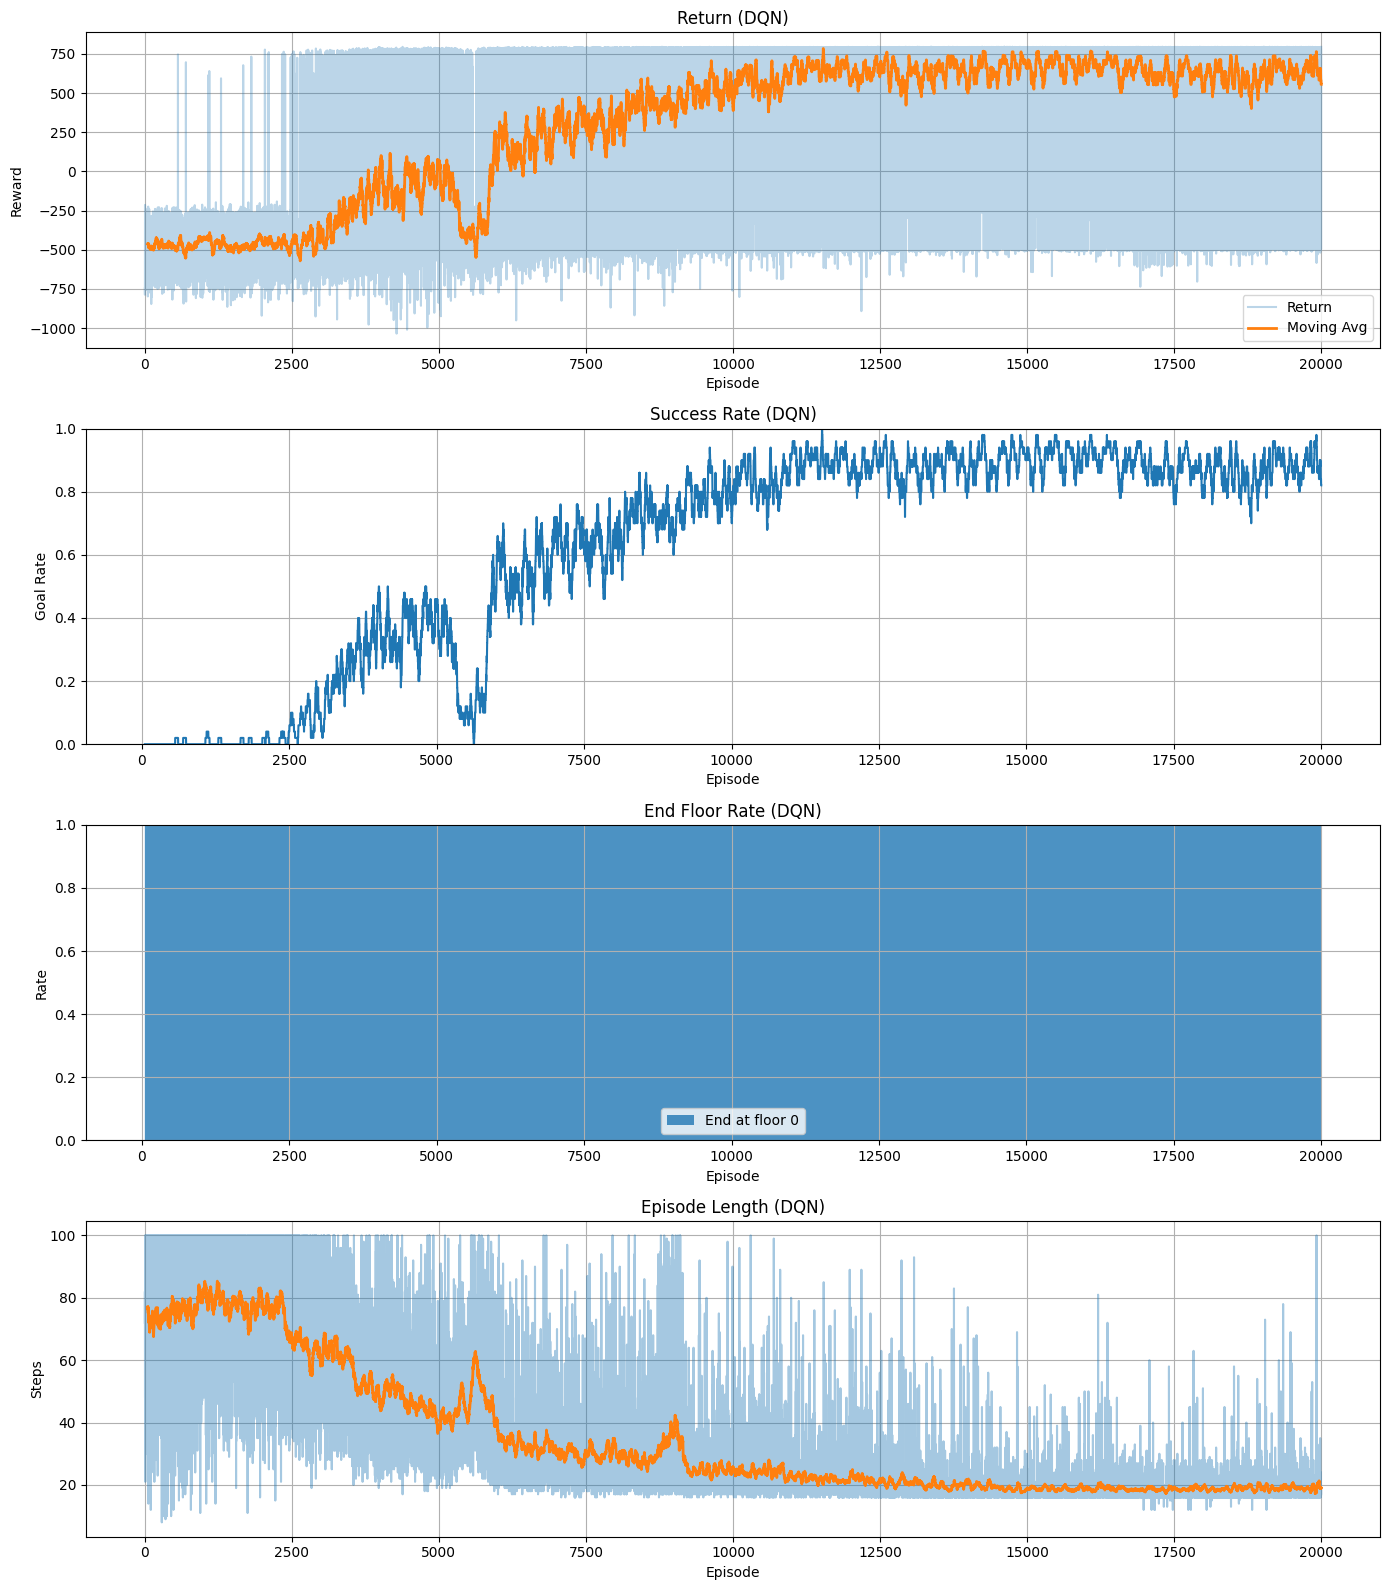

In [ ]:
# @title
DQN_EP_AMOUNT = 20000
DQN_EP_MIN = 0.1

dqn_agent = DQNAgent(
    state_dim=DQNStateProcessor.STATE_DIM,  # BẮT BUỘC khớp shape state hiện tại của env
    gamma=0.98,            # Discount factor (ưu tiên reward tương lai)
    lr=3e-4,               # Learning rate của optimizer
    hidden_dim=128,        # Số neuron mỗi nhánh MLP
    buffer_capacity=200000,# Replay buffer lớn -> mẫu đa dạng hơn nhưng tốn RAM hơn
    batch_size=64,        # Batch lớn ổn định hơn nhưng chậm/đòi GPU-RAM hơn
    tau=0.005,  # Soft update: nhỏ -> target ổn định hơn, lớn -> bám online nhanh hơn

    # epsilon_start chỉ có hiệu lực khi train mới (không load checkpoint).
    # Nếu có load_path thì epsilon có thể bị ghi đè bởi checkpoint và/hoặc epsilon_override bên dưới.
    epsilon_start=1.0,
    epsilon_min=DQN_EP_MIN,
    epsilon_decay=float(np.power(DQN_EP_MIN, 1.0 / int(DQN_EP_AMOUNT * 0.75))),
)

dqn_agent, logs = train_dqn_on_env(
    dqn_agent=dqn_agent,
    maze=maze,

    episodeAmount=DQN_EP_AMOUNT,

    fixed_map=True,        # True: 1 layout map cố định (ổn định benchmark); False: random map mỗi ep

    seed=42,               # Seed cho chuỗi env_seed (để tái lập kết quả)
    maxSteps=100,          # Giới hạn bước/episode; timeout khi chạm ngưỡng
    printAfterEpisode=int(DQN_EP_AMOUNT * 0.04),

    saveDQNModel=True,      # True để lưu checkpoint/best/final
    save_dir="/content/drive/MyDrive/DQN_PhaseF1",   # Thư mục lưu model khi saveDQNModel=True

    plot_metrics=True,     # Vẽ biểu đồ sau train
    window=50,             # Cửa sổ moving average cho metric/plot

    # load_path != None: resume từ checkpoint, model/optimizer/epsilon có thể được nạp từ file.
    load_path=None,          # Ví dụ: "DQN_Phase1/best_dqn.pt" để train tiếp
    load_map_location="cpu", # 'cpu' hoặc 'cuda'/'cuda:0'
    # epsilon_override ưu tiên cao nhất: set lại epsilon sau khi load (reheat exploration), nếu ko load thì ko set
    epsilon_override=None,
    learn_every=4,
)

# TRAINING PHASE 2:
# PHASE 2: 20k ep
# MAP cố định seed 42
# SOFT_WALL=5
# MAX_BOMB=2
# TOTAL_FLOORS=2
# maxSteps = 200

[DQN] Loaded checkpoint từ: /content/drive/MyDrive/DQN_PhaseF1/best_dqn.pt

Ep 800/20000 | avg_reward=-757.36 | success_rate=0.00 | avg_steps=107.5 | TỔNG: goal=0 death=632 timeout=39 stagnation=129 | [800 ep gần nhất]: goal=0 death=632 timeout=39 stagnation=129 | epsilon=0.884
Vị trí tầng kết thúc [800 ep]: tầng0=795 tầng1=5

Ep 1600/20000 | avg_reward=-734.35 | success_rate=0.00 | avg_steps=97.6 | TỔNG: goal=0 death=1366 timeout=53 stagnation=181 | [800 ep gần nhất]: goal=0 death=734 timeout=14 stagnation=52 | epsilon=0.782
Vị trí tầng kết thúc [800 ep]: tầng0=788 tầng1=12

Ep 2400/20000 | avg_reward=-687.03 | success_rate=0.00 | avg_steps=85.0 | TỔNG: goal=0 death=2144 timeout=60 stagnation=196 | [800 ep gần nhất]: goal=0 death=778 timeout=7 stagnation=15 | epsilon=0.692
Vị trí tầng kết thúc [800 ep]: tầng0=754 tầng1=46

Ep 3200/20000 | avg_reward=-654.88 | success_rate=0.00 | avg_steps=78.5 | TỔNG: goal=0 death=2917 timeout=63 stagnation=220 | [800 ep gần nhất]: goal=0 death=773 ti

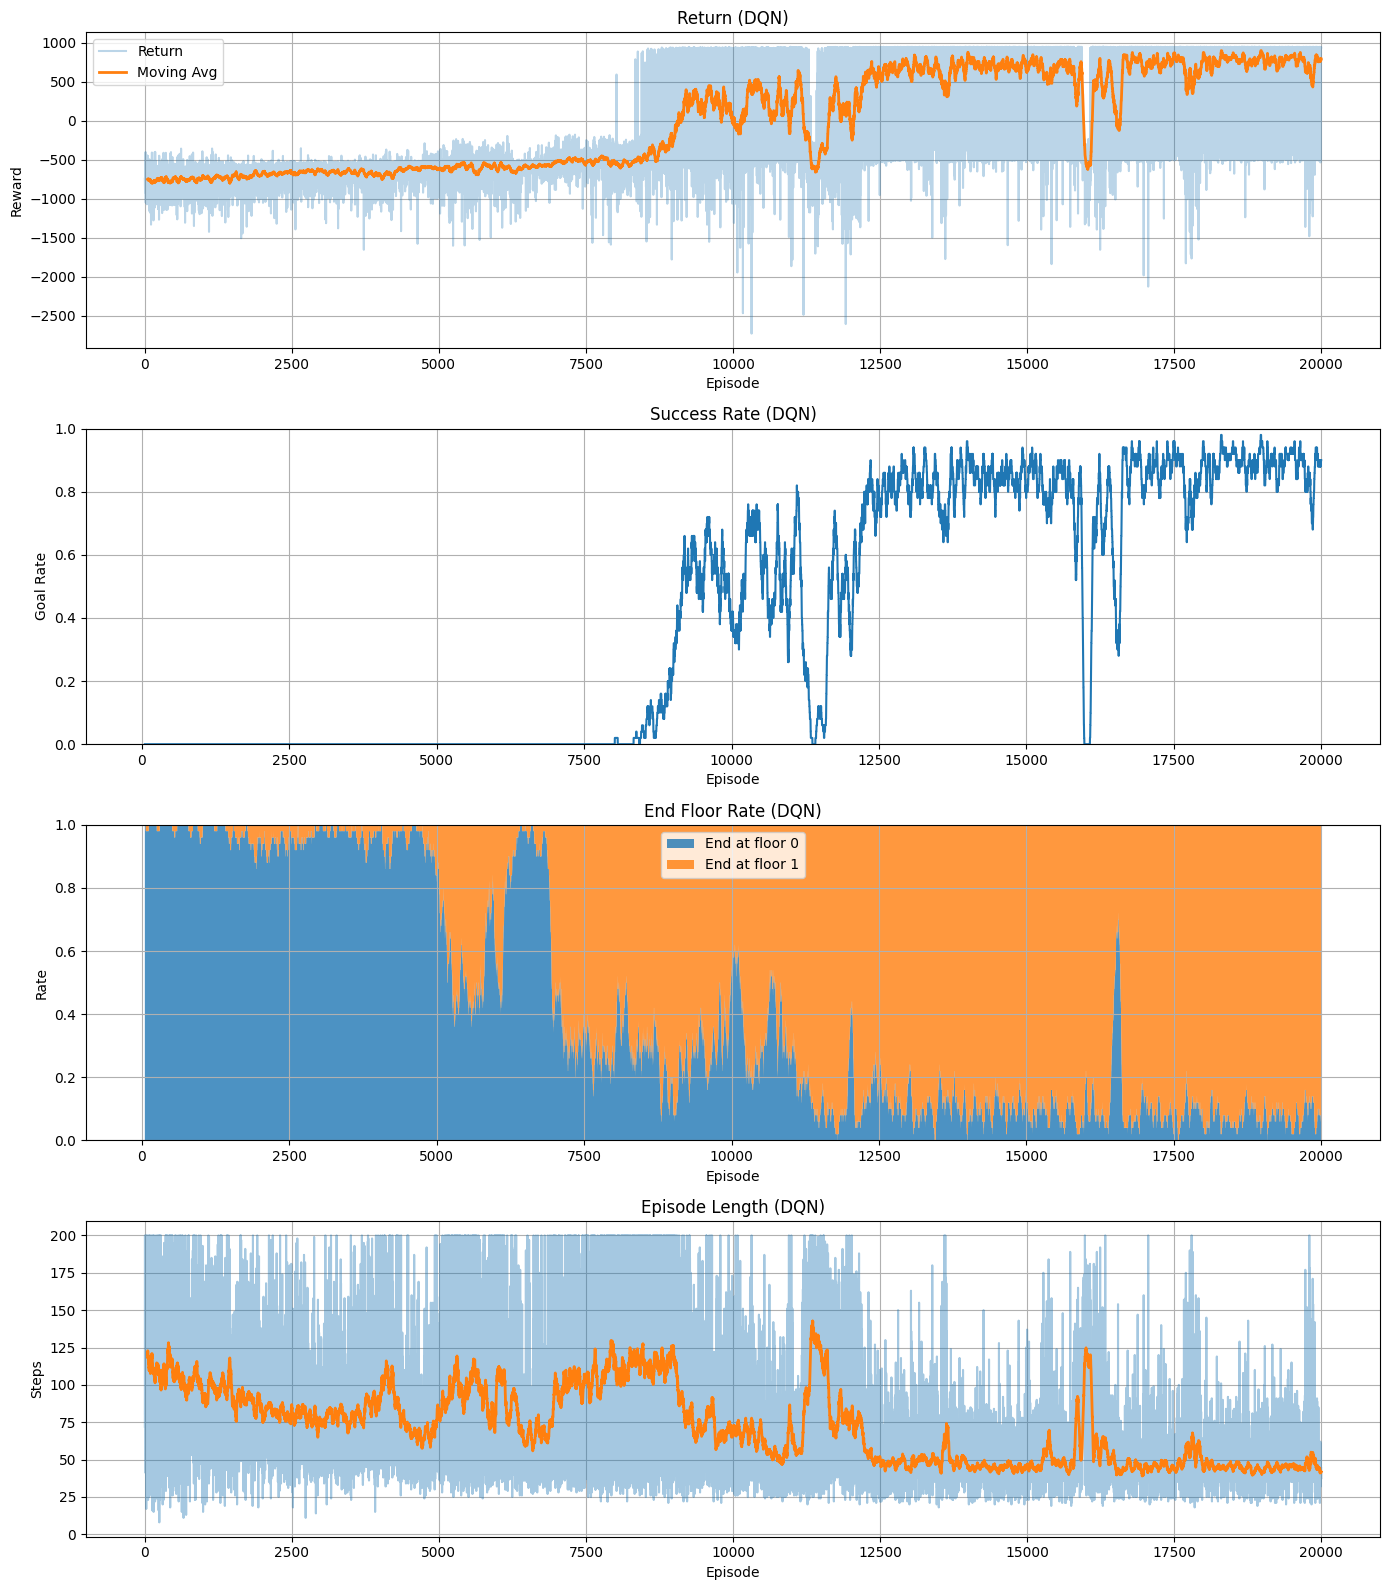

In [ ]:
# @title
DQN_EP_AMOUNT = 20000
DQN_EP_MIN = 0.1

dqn_agent = DQNAgent(
    state_dim=DQNStateProcessor.STATE_DIM,  # BẮT BUỘC khớp shape state hiện tại của env
    gamma=0.98,            # Discount factor (ưu tiên reward tương lai)
    lr=3e-4,               # Learning rate của optimizer
    hidden_dim=128,        # Số neuron mỗi nhánh MLP
    buffer_capacity=200000,# Replay buffer lớn -> mẫu đa dạng hơn nhưng tốn RAM hơn
    batch_size=64,        # Batch lớn ổn định hơn nhưng chậm/đòi GPU-RAM hơn
    tau=0.005,  # Soft update: nhỏ -> target ổn định hơn, lớn -> bám online nhanh hơn

    # epsilon_start chỉ có hiệu lực khi train mới (không load checkpoint).
    # Nếu có load_path thì epsilon có thể bị ghi đè bởi checkpoint và/hoặc epsilon_override bên dưới.
    epsilon_start=1.0,
    epsilon_min=DQN_EP_MIN,
    epsilon_decay=float(np.power(DQN_EP_MIN, 1.0 / int(DQN_EP_AMOUNT * 0.75))),
)

dqn_agent, logs = train_dqn_on_env(
    dqn_agent=dqn_agent,
    maze=maze,

    episodeAmount=DQN_EP_AMOUNT,

    fixed_map=True,        # True: 1 layout map cố định (ổn định benchmark); False: random map mỗi ep

    seed=42,               # Seed cho chuỗi env_seed (để tái lập kết quả)
    maxSteps=200,          # Giới hạn bước/episode; timeout khi chạm ngưỡng
    printAfterEpisode=int(DQN_EP_AMOUNT * 0.04),

    saveDQNModel=True,      # True để lưu checkpoint/best/final
    save_dir="/content/drive/MyDrive/DQN_PhaseF2",   # Thư mục lưu model khi saveDQNModel=True

    plot_metrics=True,     # Vẽ biểu đồ sau train
    window=50,             # Cửa sổ moving average cho metric/plot

    # load_path != None: resume từ checkpoint, model/optimizer/epsilon có thể được nạp từ file.
    load_path="/content/drive/MyDrive/DQN_PhaseF1/best_dqn.pt",          # Ví dụ: "DQN_Phase1/best_dqn.pt" để train tiếp
    load_map_location="cpu", # 'cpu' hoặc 'cuda'/'cuda:0'
    # epsilon_override ưu tiên cao nhất: set lại epsilon sau khi load (reheat exploration), nếu ko load thì ko set
    epsilon_override=1.0,
    learn_every=4,
)

# TRAINING PHASE 3:
# PHASE 3: 20k ep
# MAP cố định seed 42
# SOFT_WALL=5
# MAX_BOMB=2
# TOTAL_FLOORS=3
# maxSteps = 250

[DQN] Loaded checkpoint từ: /content/drive/MyDrive/DQN_PhaseF2/best_dqn.pt

Ep 800/20000 | avg_reward=-821.10 | success_rate=0.00 | avg_steps=114.6 | TỔNG: goal=0 death=682 timeout=17 stagnation=101 | [800 ep gần nhất]: goal=0 death=682 timeout=17 stagnation=101 | epsilon=0.884
Vị trí tầng kết thúc [800 ep]: tầng0=787 tầng1=13

Ep 1600/20000 | avg_reward=-727.77 | success_rate=0.00 | avg_steps=93.3 | TỔNG: goal=0 death=1465 timeout=23 stagnation=112 | [800 ep gần nhất]: goal=0 death=783 timeout=6 stagnation=11 | epsilon=0.782
Vị trí tầng kết thúc [800 ep]: tầng0=746 tầng1=54

Ep 2400/20000 | avg_reward=-673.06 | success_rate=0.00 | avg_steps=84.8 | TỔNG: goal=0 death=2252 timeout=33 stagnation=115 | [800 ep gần nhất]: goal=0 death=787 timeout=10 stagnation=3 | epsilon=0.692
Vị trí tầng kết thúc [800 ep]: tầng0=689 tầng1=111

Ep 3200/20000 | avg_reward=-652.16 | success_rate=0.00 | avg_steps=81.0 | TỔNG: goal=0 death=3033 timeout=40 stagnation=127 | [800 ep gần nhất]: goal=0 death=781 t

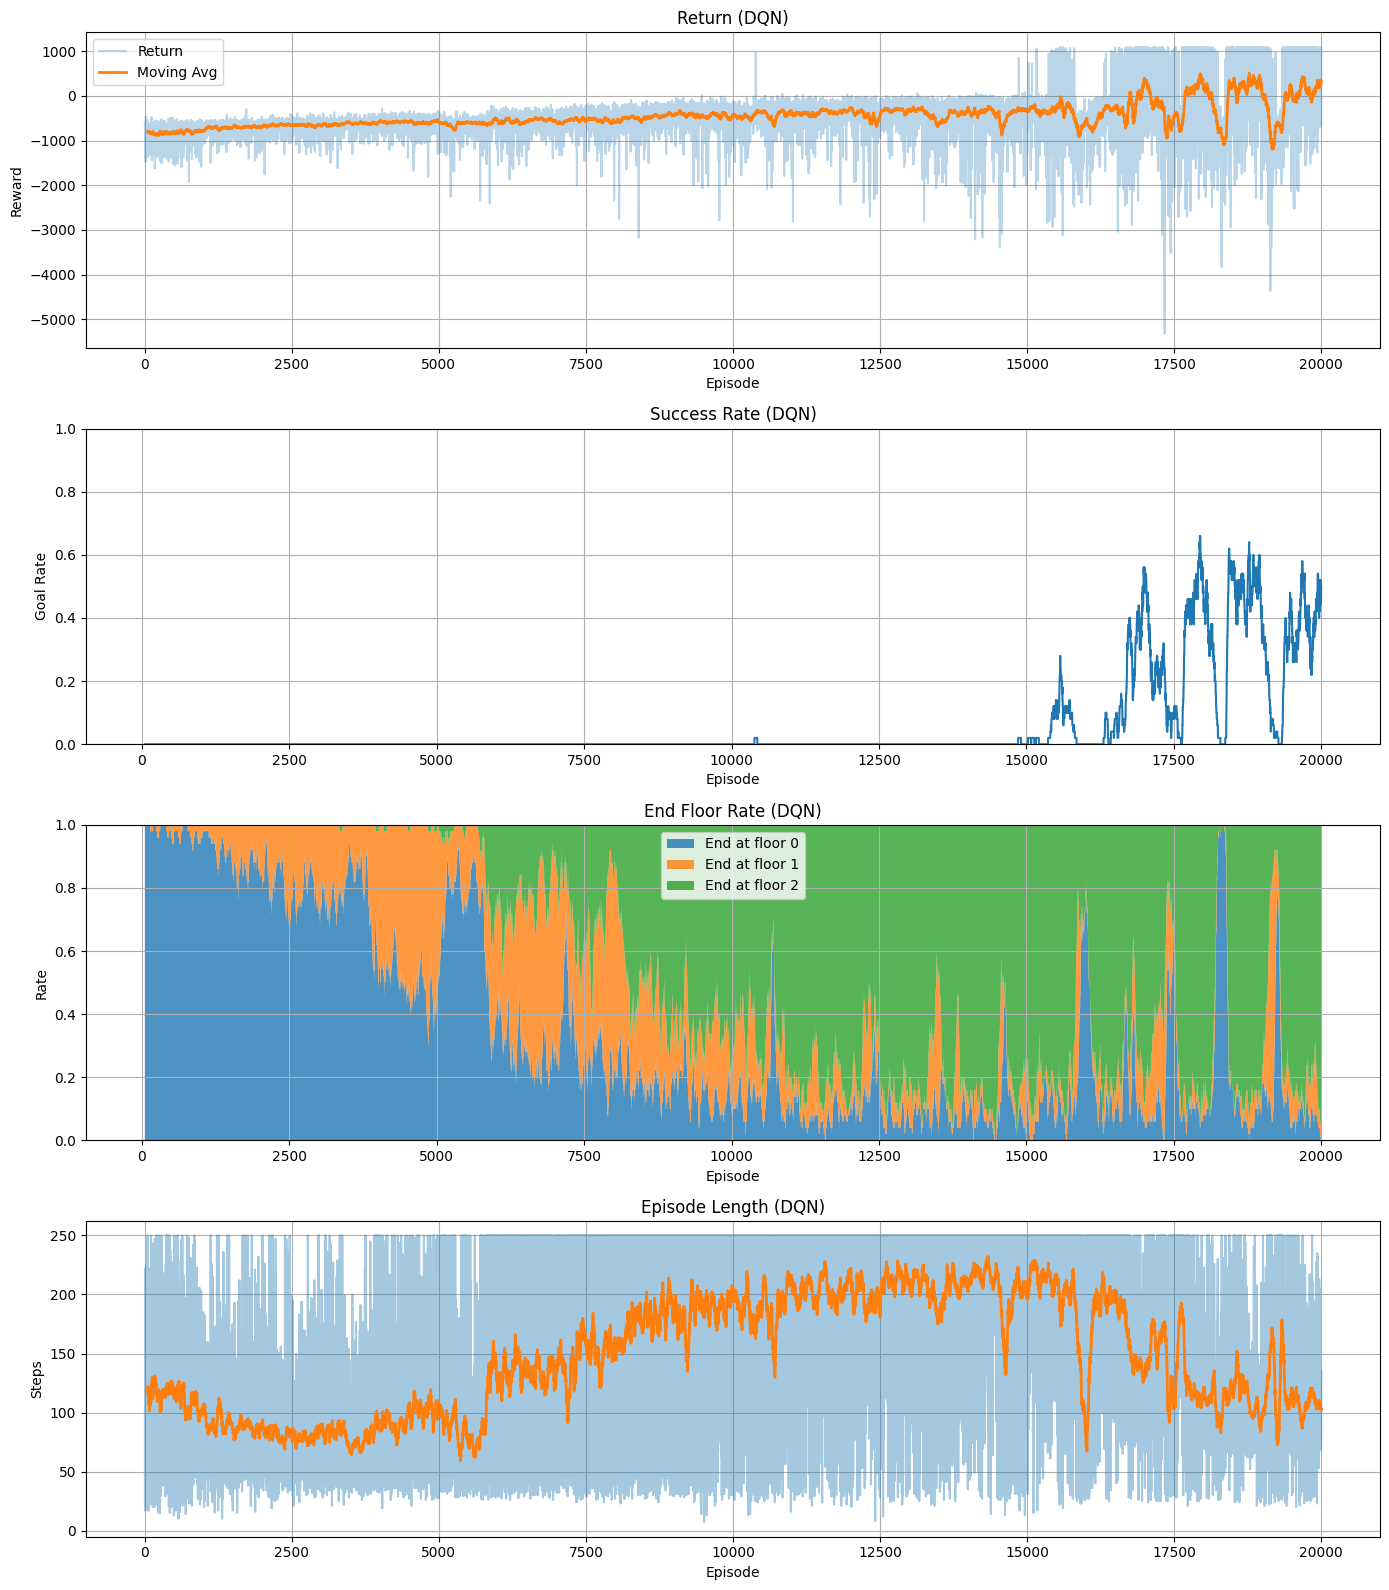

In [ ]:
# @title
DQN_EP_AMOUNT = 20000
DQN_EP_MIN = 0.1

dqn_agent = DQNAgent(
    state_dim=DQNStateProcessor.STATE_DIM,  # BẮT BUỘC khớp shape state hiện tại của env
    gamma=0.98,            # Discount factor (ưu tiên reward tương lai)
    lr=3e-4,               # Learning rate của optimizer
    hidden_dim=128,        # Số neuron mỗi nhánh MLP
    buffer_capacity=200000,# Replay buffer lớn -> mẫu đa dạng hơn nhưng tốn RAM hơn
    batch_size=64,        # Batch lớn ổn định hơn nhưng chậm/đòi GPU-RAM hơn
    tau=0.005,  # Soft update: nhỏ -> target ổn định hơn, lớn -> bám online nhanh hơn

    # epsilon_start chỉ có hiệu lực khi train mới (không load checkpoint).
    # Nếu có load_path thì epsilon có thể bị ghi đè bởi checkpoint và/hoặc epsilon_override bên dưới.
    epsilon_start=1.0,
    epsilon_min=DQN_EP_MIN,
    epsilon_decay=float(np.power(DQN_EP_MIN, 1.0 / int(DQN_EP_AMOUNT * 0.75))),
)

dqn_agent, logs = train_dqn_on_env(
    dqn_agent=dqn_agent,
    maze=maze,

    episodeAmount=DQN_EP_AMOUNT,

    fixed_map=True,        # True: 1 layout map cố định (ổn định benchmark); False: random map mỗi ep

    seed=42,               # Seed cho chuỗi env_seed (để tái lập kết quả)
    maxSteps=250,          # Giới hạn bước/episode; timeout khi chạm ngưỡng
    printAfterEpisode=int(DQN_EP_AMOUNT * 0.04),

    saveDQNModel=True,      # True để lưu checkpoint/best/final
    save_dir="/content/drive/MyDrive/DQN_PhaseF3",   # Thư mục lưu model khi saveDQNModel=True

    plot_metrics=True,     # Vẽ biểu đồ sau train
    window=50,             # Cửa sổ moving average cho metric/plot

    # load_path != None: resume từ checkpoint, model/optimizer/epsilon có thể được nạp từ file.
    load_path="/content/drive/MyDrive/DQN_PhaseF2/best_dqn.pt",          # Ví dụ: "DQN_Phase1/best_dqn.pt" để train tiếp
    load_map_location="cpu", # 'cpu' hoặc 'cuda'/'cuda:0'
    # epsilon_override ưu tiên cao nhất: set lại epsilon sau khi load (reheat exploration), nếu ko load thì ko set
    epsilon_override=1.0,
    learn_every=4,
)

# TRAINING PHASE 4:
# PHASE 4: 20k ep
# MAP RANDOM seed 42
# SOFT_WALL=5
# MAX_BOMB=2
# TOTAL_FLOORS=2
# maxSteps = 200

[DQN] Loaded checkpoint từ: /content/drive/MyDrive/DQN_PhaseF3/best_dqn.pt

Ep 800/20000 | avg_reward=-842.87 | success_rate=0.00 | avg_steps=140.7 | TỔNG: goal=0 death=524 timeout=126 stagnation=150 | [800 ep gần nhất]: goal=0 death=524 timeout=126 stagnation=150 | epsilon=0.884
Vị trí tầng kết thúc [800 ep]: tầng0=786 tầng1=14

Ep 1600/20000 | avg_reward=-841.50 | success_rate=0.00 | avg_steps=135.7 | TỔNG: goal=0 death=1123 timeout=249 stagnation=228 | [800 ep gần nhất]: goal=0 death=599 timeout=123 stagnation=78 | epsilon=0.782
Vị trí tầng kết thúc [800 ep]: tầng0=786 tầng1=14

Ep 2400/20000 | avg_reward=-818.39 | success_rate=0.00 | avg_steps=129.6 | TỔNG: goal=0 death=1751 timeout=353 stagnation=296 | [800 ep gần nhất]: goal=0 death=628 timeout=104 stagnation=68 | epsilon=0.692
Vị trí tầng kết thúc [800 ep]: tầng0=781 tầng1=19

Ep 3200/20000 | avg_reward=-836.48 | success_rate=0.00 | avg_steps=149.0 | TỔNG: goal=0 death=2313 timeout=495 stagnation=392 | [800 ep gần nhất]: goal=0 

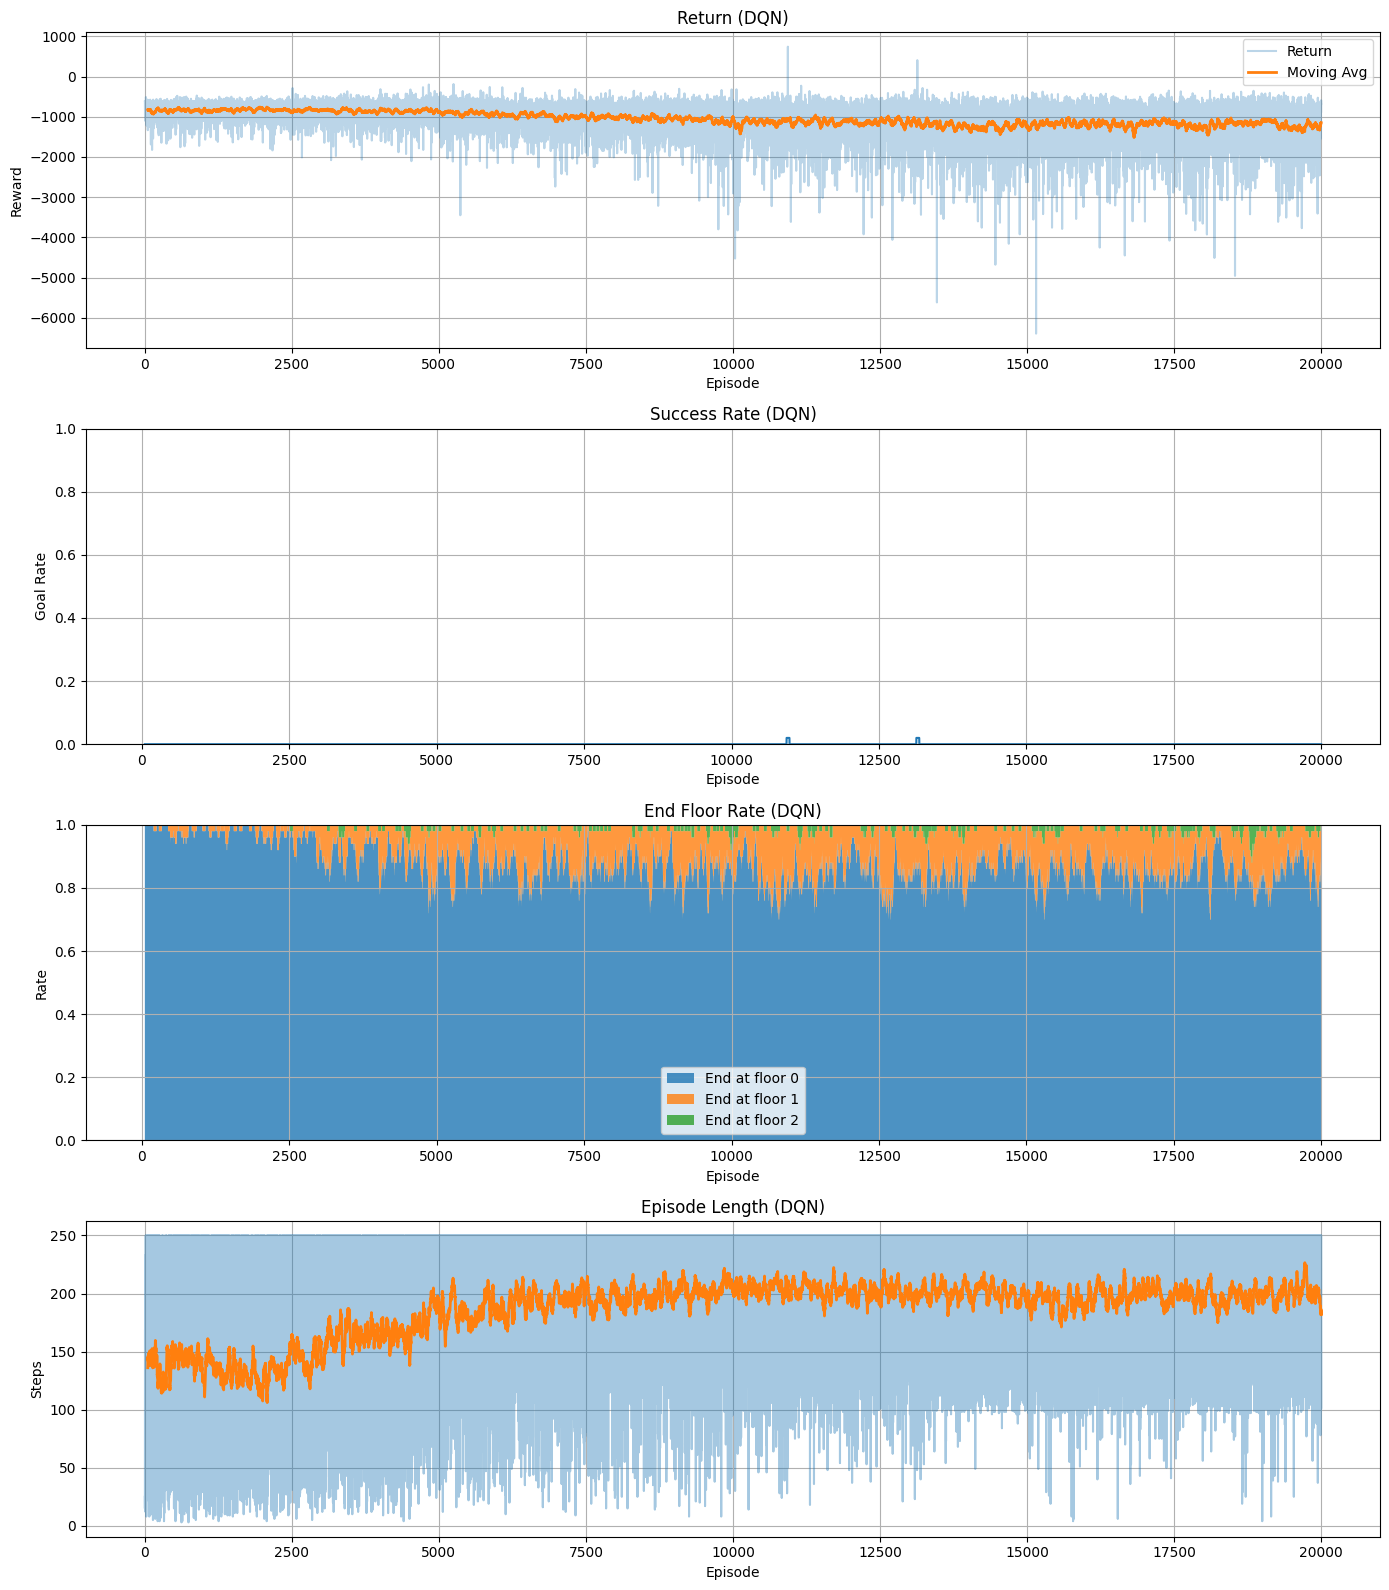

In [30]:
# @title
DQN_EP_AMOUNT = 20000
DQN_EP_MIN = 0.1

dqn_agent = DQNAgent(
    state_dim=DQNStateProcessor.STATE_DIM,  # BẮT BUỘC khớp shape state hiện tại của env
    gamma=0.98,            # Discount factor (ưu tiên reward tương lai)
    lr=3e-4,               # Learning rate của optimizer
    hidden_dim=128,        # Số neuron mỗi nhánh MLP
    buffer_capacity=200000,# Replay buffer lớn -> mẫu đa dạng hơn nhưng tốn RAM hơn
    batch_size=64,        # Batch lớn ổn định hơn nhưng chậm/đòi GPU-RAM hơn
    tau=0.005,  # Soft update: nhỏ -> target ổn định hơn, lớn -> bám online nhanh hơn

    # epsilon_start chỉ có hiệu lực khi train mới (không load checkpoint).
    # Nếu có load_path thì epsilon có thể bị ghi đè bởi checkpoint và/hoặc epsilon_override bên dưới.
    epsilon_start=1.0,
    epsilon_min=DQN_EP_MIN,
    epsilon_decay=float(np.power(DQN_EP_MIN, 1.0 / int(DQN_EP_AMOUNT * 0.75))),
)

dqn_agent, logs = train_dqn_on_env(
    dqn_agent=dqn_agent,
    maze=maze,

    episodeAmount=DQN_EP_AMOUNT,

    fixed_map=False,        # True: 1 layout map cố định (ổn định benchmark); False: random map mỗi ep

    seed=42,               # Seed cho chuỗi env_seed (để tái lập kết quả)
    maxSteps=250,          # Giới hạn bước/episode; timeout khi chạm ngưỡng
    printAfterEpisode=int(DQN_EP_AMOUNT * 0.04),

    saveDQNModel=True,      # True để lưu checkpoint/best/final
    save_dir="/content/drive/MyDrive/DQN_PhaseF4",   # Thư mục lưu model khi saveDQNModel=True

    plot_metrics=True,     # Vẽ biểu đồ sau train
    window=50,             # Cửa sổ moving average cho metric/plot

    # load_path != None: resume từ checkpoint, model/optimizer/epsilon có thể được nạp từ file.
    load_path="/content/drive/MyDrive/DQN_PhaseF3/best_dqn.pt",          # Ví dụ: "DQN_Phase1/best_dqn.pt" để train tiếp
    load_map_location="cpu", # 'cpu' hoặc 'cuda'/'cuda:0'
    # epsilon_override ưu tiên cao nhất: set lại epsilon sau khi load (reheat exploration), nếu ko load thì ko set
    epsilon_override=1.0,
    learn_every=4,
)